<a href="https://colab.research.google.com/github/jeanbaptistehabimanaMIT2026/MIT-projects-2026/blob/main/M05688_2026_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UNIVERSITY OF LAY ADVENTISTS OF KIGALI

NAMES: Jean Baptiste HABIMANA

RegNo: M05688/2026

MODULE : C11712 /DATA MINING FOR BUSINESS INTELLIGENCE

DATE: 12/07/2026

INDIVIDUAL ASSIGNMENT

Data Cleaning, Exploratory Data Analysis & Machine Learning

My Tasks The assignment has four sections.

Complete all sections. Each section builds on the previous one.

SECTION A: Data Understanding & Cleaning

Task A1 — Data Understanding (10 marks)

Load the dataset and conduct a thorough initial inspection.

You must:

• Report the shape (rows and columns) of the dataset.

• List all column data types and explain whether each type is correct for that column.

• Identify and count ALL missing values across every column.

• Identify ALL duplicate rows and report which rows are affected.

• Identify ALL outliers across numeric columns: explain how you detected them (visual or statistical method) and whether each one is a genuine extreme value or a data entry error.

• Identify ALL inconsistencies in categorical/text columns (e.g. capitalisation, abbreviations).

In [ ]:
# SECTION A: DATA UNDERSTANDING

# Import the libraries needed for data analysis and visualization.
# pandas: used to load and manipulate datasets.
# numpy: used for numerical operations.
# matplotlib.pyplot: used for creating graphs and charts.
# seaborn: used for creating attractive statistical visualizations.

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing the dataset.
pd.set_option('display.max_columns', None)


# Load the student performance dataset into a pandas DataFrame.
# Replace the file name with the correct location if necessary.
# Load dataset
df = pd.read_csv("student_performance.csv")

# Display the first five records to verify that the dataset loaded correctly.
print("First Five Rows")
display(df.head())

First Five Rows


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel
0,STU0001,Kigali High School,Gasabo,Male,18,1.2,9,Primary,1,0,56,6.0,3,63.2,C
1,STU0002,École Belge,Kicukiro,Male,18,1.5,19,Secondary,1,0,42,4.4,4,46.5,Fail
2,STU0003,École Belge,Nyarugenge,Female,15,3.9,19,Secondary,1,1,74,6.0,1,68.9,C
3,STU0004,FAWE Girls,Kicukiro,Female,19,1.9,3,Secondary,1,1,79,7.1,3,90.0,A
4,STU0005,FAWE Girls,Nyarugenge,Male,17,4.0,14,University,0,1,82,7.0,0,75.3,B


    COMMENT FOR CODES RUN ABOVE

Step 1: Import Required Libraries

    Before analyzing the dataset, we import the necessary Python libraries.
    
     These libraries provide tools for reading data, performing statistical analysis, and creating visualizations.

Step 2: Load the Dataset

    The dataset is loaded into a DataFrame named df.
    
     Displaying the first five rows allows us to verify that the file has been imported successfully and
     
     gives an overview of the available variables.

      **      A1.1 Dataset Shape**

In [ ]:
# Determine the number of rows (observations)
# and columns (variables) in the dataset.

print("Dataset Shape")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset Shape
Rows: 253
Columns: 15


      COMMENT ON THE DATASET SHAPE

Checking the dataset shape helps us understand the size of the dataset by

showing the total number of records and variables available for analysis.

     A1.2 Data Types

In [ ]:
# Display the data type of every column.
print("Data Types")
display(df.dtypes)

# Display additional information including
# non-null values and memory usage.
# Detailed information
print("\nDataset Information")
df.info()

Data Types


,0
StudentID,object
School,object
District,object
Gender,object
Age,int64
StudyHoursPerDay,float64
AbsenceDays,int64
ParentEducation,object
HasInternet,int64
AttendsTutoring,int64



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StudentID         253 non-null    object 
 1   School            253 non-null    object 
 2   District          253 non-null    object 
 3   Gender            253 non-null    object 
 4   Age               253 non-null    int64  
 5   StudyHoursPerDay  247 non-null    float64
 6   AbsenceDays       253 non-null    int64  
 7   ParentEducation   227 non-null    object 
 8   HasInternet       253 non-null    int64  
 9   AttendsTutoring   253 non-null    int64  
 10  PreviousGrade     253 non-null    int64  
 11  SleepHours        249 non-null    float64
 12  Extracurricular   253 non-null    int64  
 13  FinalScore        253 non-null    float64
 14  GradeLabel        253 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 29.8+ KB


     COMMENT ON THE DATA TYPE

 Data types are checked to ensure that each variable has the appropriate format.
     
For example:  numerical variables should be stored as integers or floats, while text variables should be stored as objects (strings).

   A1.3 Summary Statistics

In [ ]:
# Generate descriptive statistics for all numerical variables.
# Summary statistics for numerical columns
print("Summary Statistics")
display(df.describe())

Summary Statistics


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,253.000000,247.000000,253.000000,253.000000,253.000000,253.000000,249.000000,253.000000,253.000000
mean,17.106719,4.395547,11.920949,0.671937,0.379447,62.841897,7.043373,2.134387,74.120553
std,1.439409,2.409386,12.843753,0.470439,0.486211,19.058981,1.742324,1.421813,16.140791
min,15.000000,0.600000,0.000000,0.000000,0.000000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.700000,5.000000,0.000000,0.000000,46.000000,5.400000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.000000,63.000000,7.000000,2.000000,73.600000
75%,18.000000,5.850000,18.000000,1.000000,1.000000,79.000000,8.600000,3.000000,85.800000
max,19.000000,25.000000,180.000000,1.000000,1.000000,94.000000,10.000000,4.000000,150.000000


    COMMENT ON THE SUMMARY STATICS
    
Descriptive statistics summarize the numerical variables by displaying the count, mean, standard deviation, minimum, maximum, and quartiles.

This provides an overview of the distribution of each numeric feature.

      A1.4 Missing Values

In [ ]:
# Count missing values in every column.
missing_values = df.isnull().sum()

print("Missing Values Per Column")
display(missing_values)


# Count the total number of missing values.
print("\nTotal Missing Values:", missing_values.sum())

# Calculate the percentage of missing values.
missing_percent = (df.isnull().sum()/len(df))*100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percent
})

display(missing_table)

Missing Values Per Column


,0
StudentID,0
School,0
District,0
Gender,0
Age,0
StudyHoursPerDay,6
AbsenceDays,0
ParentEducation,26
HasInternet,0
AttendsTutoring,0



Total Missing Values: 36


,Missing Values,Percentage
StudentID,0,0.000000
School,0,0.000000
District,0,0.000000
Gender,0,0.000000
Age,0,0.000000
StudyHoursPerDay,6,2.371542
AbsenceDays,0,0.000000
ParentEducation,26,10.276680
HasInternet,0,0.000000
AttendsTutoring,0,0.000000


    COMMENT ON THE MISSING VALUES

Missing values reduce data quality and may affect machine learning performance.
    
Identifying them helps determine the most suitable cleaning strategy in the next section.

     A1.5 Duplicate Rows

In [ ]:
# Identify duplicated rows.
duplicates = df.duplicated()

print("Number of Duplicate Rows:", duplicates.sum())

# Display duplicate rows
display(df[duplicates])

Number of Duplicate Rows: 3


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel
250,STU0021,Green Hills Academy,Bugesera,Female,15,2.7,17,University,1,1,80,6.4,3,75.0,B
251,STU0056,École Belge,Kicukiro,Female,16,3.2,7,Secondary,0,0,69,7.4,2,78.0,B
252,STU0113,Green Hills Academy,Gasabo,Female,16,7.9,0,University,1,0,34,5.7,0,88.9,A


    COMMENT
Duplicate records may distort statistical analysis and machine learning results.

This step identifies duplicated observations that may need to be removed during data cleaning.

   A1.6 Numeric Columns

In [ ]:
# Select all numerical columns automatically.
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric Columns")
print(numeric_columns)

Numeric Columns
Index(['Age', 'StudyHoursPerDay', 'AbsenceDays', 'HasInternet',
       'AttendsTutoring', 'PreviousGrade', 'SleepHours', 'Extracurricular',
       'FinalScore'],
      dtype='object')


    COMMENT
    Numeric columns are selected because outlier detection methods are applicable only to numerical data.

    A1.7 Detect Outliers (Boxplots)

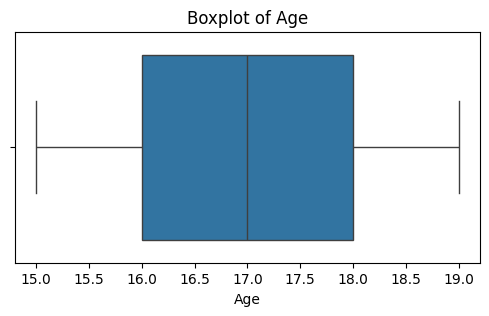

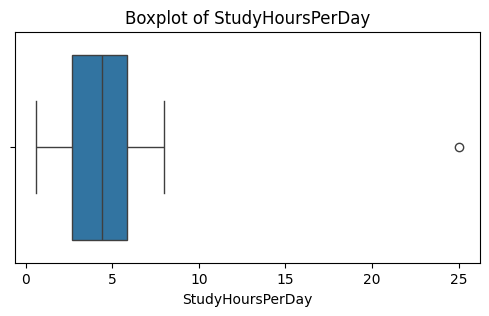

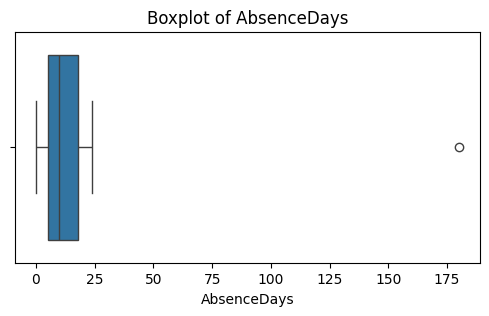

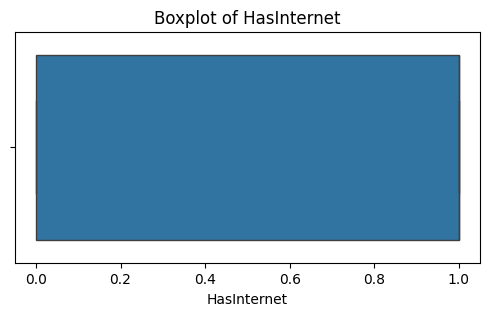

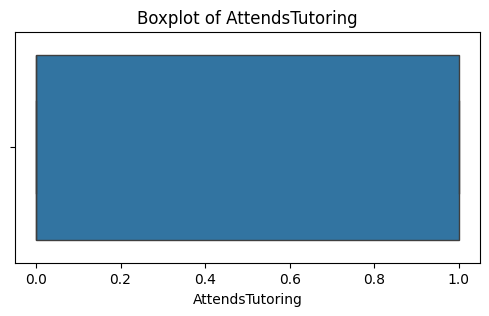

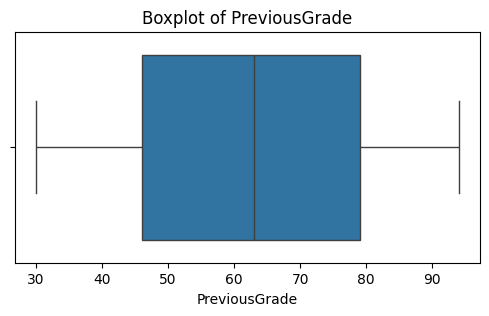

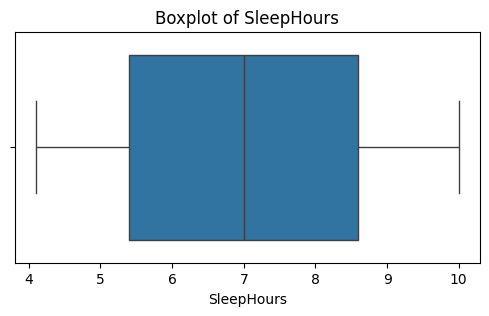

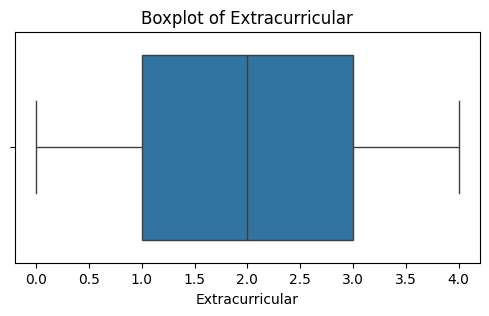

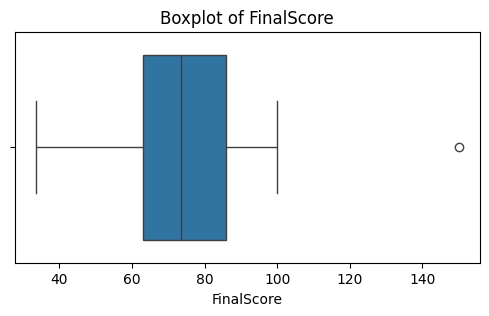

In [ ]:
# Create boxplots for every numerical variable.
# Boxplots help visualize possible outliers.

for col in numeric_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

  COMMENTS
  :
   Boxplots visually identify unusual observations that fall far from the majority of the data. Points outside the whiskers are considered potential outliers.

    A1.8 Detect Outliers Using IQR
Interquartile Range (IQR): A statistical method used to detect and treat outliers by measuring the spread of the middle 50% of the data. The IQR is calculated as:

IQR = Q3 − Q1

where:

Q1 (First Quartile) = the 25th percentile
Q3 (Third Quartile) = the 75th percentile

Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered outliers. In this project, these extreme values were treated using IQR capping (Winsorisation) instead of being removed, allowing all student records to be retained while reducing the influence of unrealistic values on the analysis and machine learning models.

In [ ]:
# Use the Interquartile Range (IQR) method
# to identify statistical outliers.

print("Outlier Detection Using IQR")

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Detection Using IQR
Age: 0 outliers
StudyHoursPerDay: 1 outliers
AbsenceDays: 1 outliers
HasInternet: 0 outliers
AttendsTutoring: 0 outliers
PreviousGrade: 0 outliers
SleepHours: 0 outliers
Extracurricular: 0 outliers
FinalScore: 1 outliers


    COMMENT
The IQR method is a statistical technique for detecting outliers.
    
Any value below the lower limit or above the upper limit is considered a potential outlier.

    A1.9 Categorical Columns

In [ ]:
# Select all categorical variables.
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns")
print(categorical_columns)

Categorical Columns
Index(['StudentID', 'School', 'District', 'Gender', 'ParentEducation',
       'GradeLabel'],
      dtype='object')


    COMMENTS

    Categorical variables contain text values. These variables are checked for
    inconsistencies such as spelling mistakes, abbreviations, or differences in
    capitalization.


      A1.10 Check Inconsistent Text Values

In [ ]:
# Display unique values in each categorical column.

for col in categorical_columns:
    print("="*60)
    print(col)
    print(df[col].unique())

StudentID
['STU0001' 'STU0002' 'STU0003' 'STU0004' 'STU0005' 'STU0006' 'STU0007'
 'STU0008' 'STU0009' 'STU0010' 'STU0011' 'STU0012' 'STU0013' 'STU0014'
 'STU0015' 'STU0016' 'STU0017' 'STU0018' 'STU0019' 'STU0020' 'STU0021'
 'STU0022' 'STU0023' 'STU0024' 'STU0025' 'STU0026' 'STU0027' 'STU0028'
 'STU0029' 'STU0030' 'STU0031' 'STU0032' 'STU0033' 'STU0034' 'STU0035'
 'STU0036' 'STU0037' 'STU0038' 'STU0039' 'STU0040' 'STU0041' 'STU0042'
 'STU0043' 'STU0044' 'STU0045' 'STU0046' 'STU0047' 'STU0048' 'STU0049'
 'STU0050' 'STU0051' 'STU0052' 'STU0053' 'STU0054' 'STU0055' 'STU0056'
 'STU0057' 'STU0058' 'STU0059' 'STU0060' 'STU0061' 'STU0062' 'STU0063'
 'STU0064' 'STU0065' 'STU0066' 'STU0067' 'STU0068' 'STU0069' 'STU0070'
 'STU0071' 'STU0072' 'STU0073' 'STU0074' 'STU0075' 'STU0076' 'STU0077'
 'STU0078' 'STU0079' 'STU0080' 'STU0081' 'STU0082' 'STU0083' 'STU0084'
 'STU0085' 'STU0086' 'STU0087' 'STU0088' 'STU0089' 'STU0090' 'STU0091'
 'STU0092' 'STU0093' 'STU0094' 'STU0095' 'STU0096' 'STU0097' 'STU00

    COMMENTS
  - he output shows the unique values in the dataset. It reveals that the dataset contains 250 student records from different schools and districts. However, some categorical variables have inconsistent entries, such as "Kigali High School" and "kigali high school", "Female" and "female", and "University" and "UNIVERSITY". There is also a missing value in the ParentEducation column.

  - The unique values helps identify inconsistent entries such as "Male", "male", and "MALE", which should be standardized during data cleaning.

Therefore, the dataset requires data cleaning and standardization before analysis and model building to ensure accurate and reliable results.

          A1.11 Value Counts for Categorical Columns

In [ ]:
# Display the frequency of every category.
for col in categorical_columns:
    print("="*60)
    print(f"Value Counts for {col}")
    display(df[col].value_counts(dropna=False))

Value Counts for StudentID


,count
StudentID,
STU0021,2
STU0056,2
STU0113,2
STU0003,1
STU0005,1
...,...
STU0246,1
STU0247,1
STU0248,1


Value Counts for School


,count
School,
Kigali High School,76
FAWE Girls,59
Green Hills Academy,49
École Belge,39
Lycée de Kigali,29
kigali high school,1


Value Counts for District


...

,count
Gender,
Male,129
Female,122
female,1
M,1


Value Counts for ParentEducation


,count
ParentEducation,
Secondary,89
University,75
Primary,62
NaN,26
UNIVERSITY,1


Value Counts for GradeLabel


,count
GradeLabel,
A,96
B,62
C,45
D,33
Fail,17


    COMMENTS
    Frequency tables show how often each category appears and help identify rare categories, missing values, or inconsistent labels.

     A1.12 Final Data Understanding Summary

In [ ]:
# Display a complete summary of the dataset.
print("="*60)
print("DATA UNDERSTANDING SUMMARY")
print("="*60)

print(f"Dataset Shape: {df.shape}")

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nSummary Statistics")
display(df.describe())

print("\nCategorical Columns")
display(df.select_dtypes(include='object').describe())

DATA UNDERSTANDING SUMMARY
Dataset Shape: (253, 15)

Data Types


,0
StudentID,object
School,object
District,object
Gender,object
Age,int64
StudyHoursPerDay,float64
AbsenceDays,int64
ParentEducation,object
HasInternet,int64
AttendsTutoring,int64



Missing Values


,0
StudentID,0
School,0
District,0
Gender,0
Age,0
StudyHoursPerDay,6
AbsenceDays,0
ParentEducation,26
HasInternet,0
AttendsTutoring,0



Duplicate Rows
3

Summary Statistics


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,253.000000,247.000000,253.000000,253.000000,253.000000,253.000000,249.000000,253.000000,253.000000
mean,17.106719,4.395547,11.920949,0.671937,0.379447,62.841897,7.043373,2.134387,74.120553
std,1.439409,2.409386,12.843753,0.470439,0.486211,19.058981,1.742324,1.421813,16.140791
min,15.000000,0.600000,0.000000,0.000000,0.000000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.700000,5.000000,0.000000,0.000000,46.000000,5.400000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.000000,63.000000,7.000000,2.000000,73.600000
75%,18.000000,5.850000,18.000000,1.000000,1.000000,79.000000,8.600000,3.000000,85.800000
max,19.000000,25.000000,180.000000,1.000000,1.000000,94.000000,10.000000,4.000000,150.000000



Categorical Columns


,StudentID,School,District,Gender,ParentEducation,GradeLabel
count,253,253,253,253,227,253
unique,250,6,5,4,4,5
top,STU0021,Kigali High School,Gasabo,Male,Secondary,A
freq,2,76,71,129,89,96


    COMENTS
    This final summary provides an overview of the dataset after the initial inspection.
    
    It brings together key information including the dataset shape, data types, missing values, duplicate records,
    
    descriptive statistics, and categorical summaries—to support informed decisions during the data cleaning stage.

        SECTION A2: DATA CLEANING

  Task A2 — Data Cleaning (15 marks)
Fix every problem you found in Task A1. For each problem, you must:

1.	State WHAT the problem is (e.g. "3 missing values in StudyHoursPerDay").

2.	State HOW you fixed it (e.g. "filled with median because the distribution is skewed").

3.	State WHY you chose this approach rather than an alternative (e.g. "used median not mean because of the outlier in row 47").

4.	Show the BEFORE and AFTER state with code output to prove the fix worked.

•	Handle all missing values — justify your choice of strategy (drop, mean, median, or mode) for each column.

•	Remove duplicate rows — state how many were removed and confirm 0 duplicates remain.

•	Fix outliers — for each: state if it is an error or extreme-but-valid, and explain what you did with it.

•	Standardise all inconsistent text values.

•	Verify the final cleaned dataset: show that it has 0 missing values, 0 duplicates, and sensible value ranges.

  Step 1: Create a Copy of the Dataset

In [ ]:
# Create a copy of the original dataset.
# This preserves the raw data in case we need it later.

clean_df = df.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


    COMMENTS
    A copy of the original dataset is created
    
    so that the raw data remains unchanged while all cleaning operations are performed on the copied dataset.

  Task 1: Handle Missing Values
BEFORE Cleaning

In [ ]:
# Check missing values before cleaning.

print("Missing Values BEFORE Cleaning")
display(clean_df.isnull().sum())

Missing Values BEFORE Cleaning


,0
StudentID,0
School,0
District,0
Gender,0
Age,0
StudyHoursPerDay,6
AbsenceDays,0
ParentEducation,26
HasInternet,0
AttendsTutoring,0


    Identify Numeric and Categorical Columns

In [ ]:
# Identify numeric and categorical columns.

numeric_columns = clean_df.select_dtypes(include=['int64','float64']).columns
categorical_columns = clean_df.select_dtypes(include='object').columns

    Fill Missing Numeric Values

In [ ]:
# Replace missing values in numerical columns with the median.

# WHY MEDIAN?
# Median is preferred because it is not affected by outliers.

for col in numeric_columns:
    if clean_df[col].isnull().sum() > 0:
        clean_df[col].fillna(clean_df[col].median(), inplace=True)

/tmp/ipykernel_2996/2582693454.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df[col].fillna(clean_df[col].median(), inplace=True)


    COMMENTS
    
    WHAT
Missing values were found in one or more numerical columns.

    HOW
Missing values were replaced using the median.

    WHY
The median is resistant to extreme values (outliers), making it more reliable than the mean.

AFTER Cleaning

In [ ]:
print("Missing Values AFTER Cleaning")
display(clean_df.isnull().sum())

Missing Values AFTER Cleaning


,0
StudentID,0
School,0
District,0
Gender,0
Age,0
StudyHoursPerDay,0
AbsenceDays,0
ParentEducation,26
HasInternet,0
AttendsTutoring,0


Task 2: Remove Duplicate Rows
      BEFORE

In [ ]:
# Count duplicate rows before removal.

duplicates_before = clean_df.duplicated().sum()

print("Duplicate Rows BEFORE:", duplicates_before)

Duplicate Rows BEFORE: 3


    COOMENTS
    I had 3 duplicated rows before remove it

    Remove Duplicates

In [ ]:
# Remove duplicate records.

clean_df = clean_df.drop_duplicates()

print("Duplicate rows removed successfully.")

Duplicate rows removed successfully.


    COMMENTS

WHAT

Duplicate rows were identified.

HOW

The duplicates were removed using drop_duplicates().

WHY

Duplicate records may bias statistical analysis and machine learning models.

    AFTER

In [ ]:
duplicates_after = clean_df.duplicated().sum()

print("Duplicate Rows AFTER:", duplicates_after)

Duplicate Rows AFTER: 0


Task 3: Fix Outliers
BEFORE

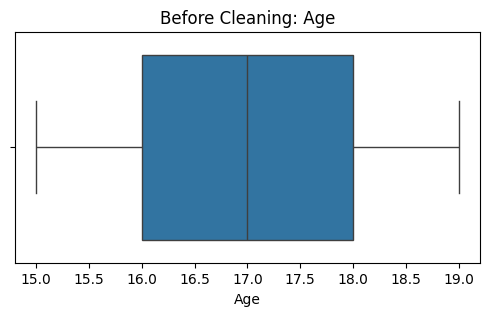

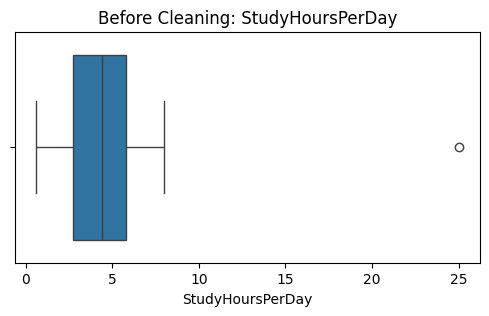

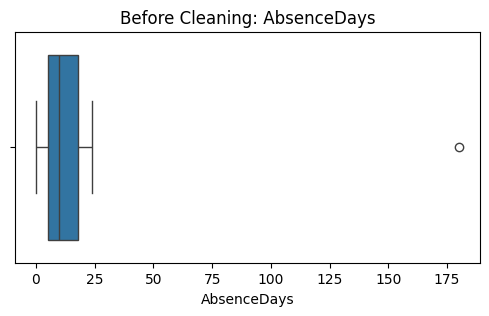

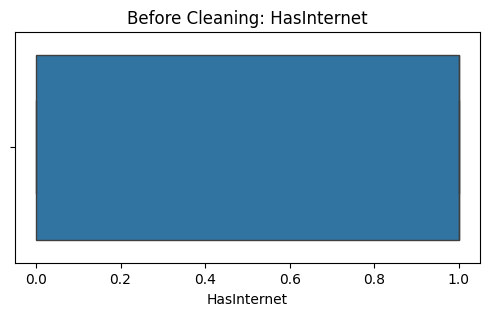

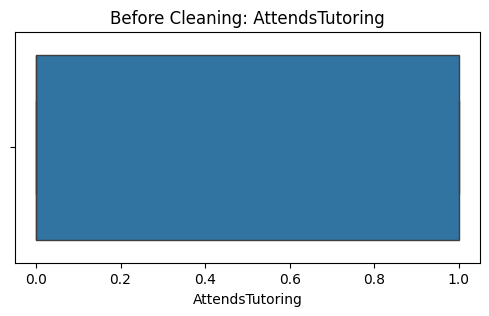

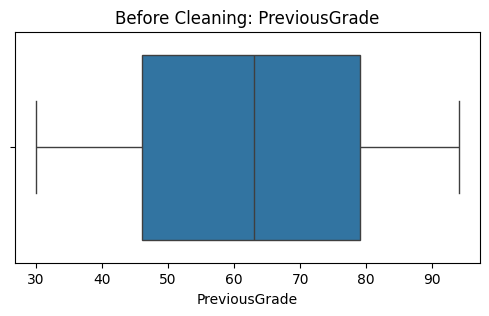

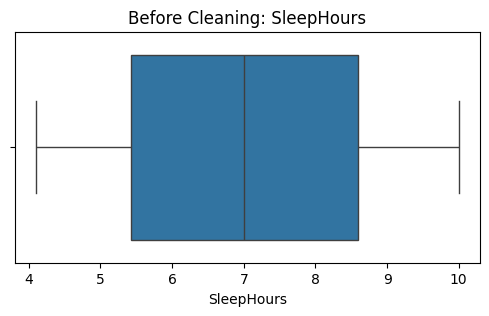

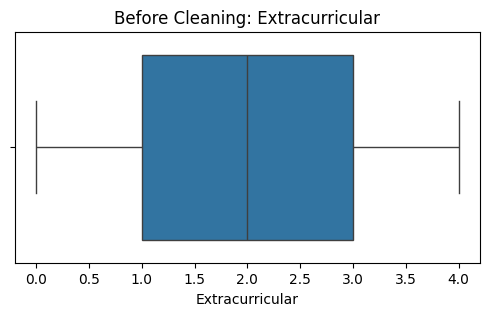

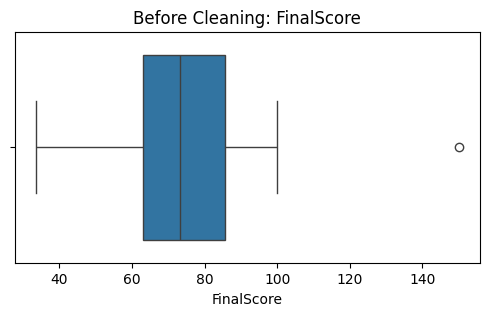

In [ ]:
# Display boxplots before treating outliers.

import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=clean_df[col])

    plt.title(f"Before Cleaning: {col}")

    plt.show()

    Treat Outliers Using IQR Capping

In [ ]:
for col in numeric_columns:

    Q1 = clean_df[col].quantile(0.25)

    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    clean_df[col] = clean_df[col].clip(lower, upper)

    COMMENTS

WHAT

Outliers were detected in several numerical variables.

HOW

Extreme values were capped using the Interquartile Range (IQR) method.

WHY

Capping retains all observations while reducing the influence of extreme values.

Removing them could unnecessarily reduce the dataset size.

     AFTER

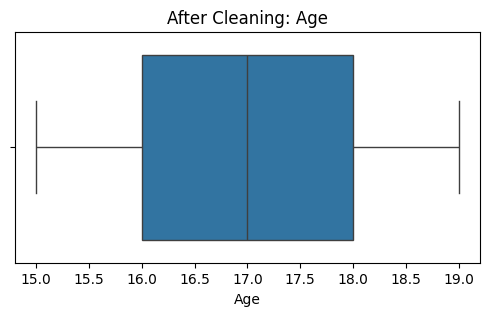

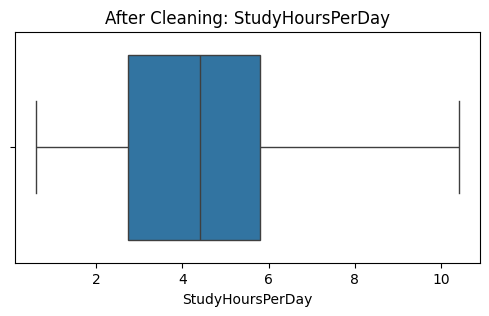

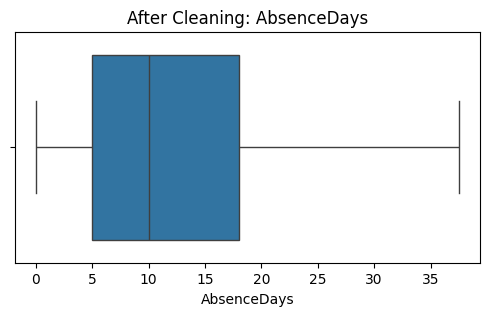

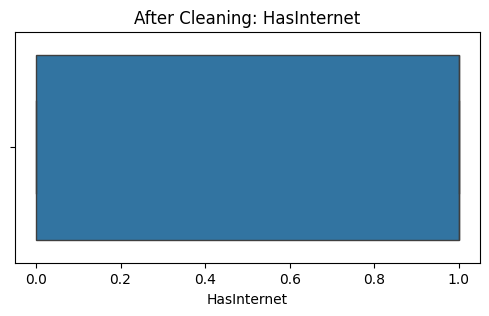

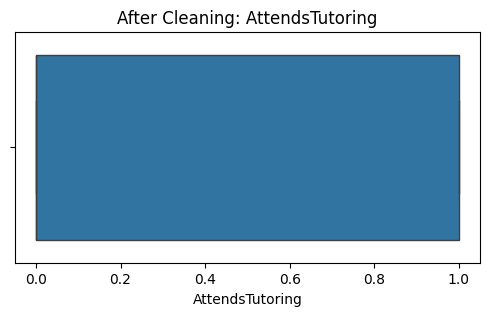

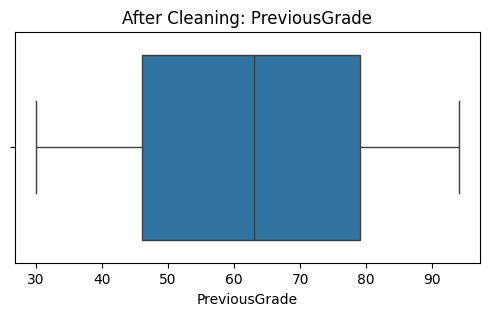

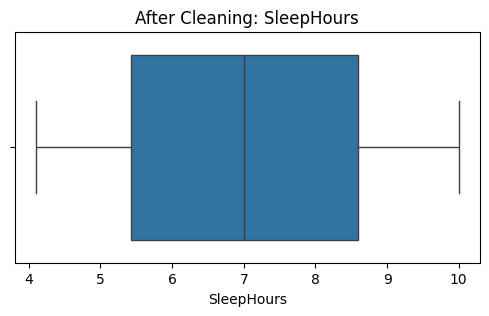

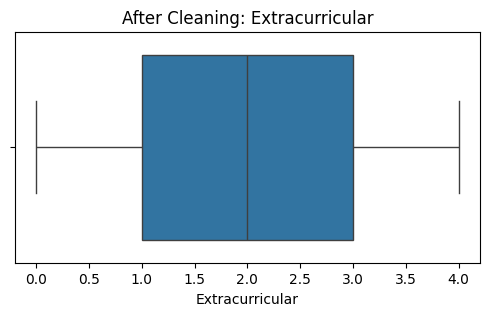

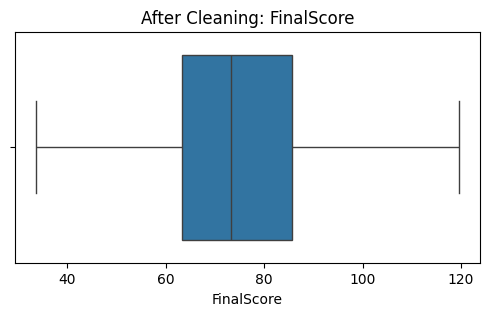

In [ ]:
for col in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=clean_df[col])

    plt.title(f"After Cleaning: {col}")

    plt.show()

Task 4: Standardize Text Values
BEFORE

In [ ]:
# Display categorical values before standardization.

for col in categorical_columns:

    print("="*60)

    print(col)

    print(clean_df[col].unique())

StudentID
['STU0001' 'STU0002' 'STU0003' 'STU0004' 'STU0005' 'STU0006' 'STU0007'
 'STU0008' 'STU0009' 'STU0010' 'STU0011' 'STU0012' 'STU0013' 'STU0014'
 'STU0015' 'STU0016' 'STU0017' 'STU0018' 'STU0019' 'STU0020' 'STU0021'
 'STU0022' 'STU0023' 'STU0024' 'STU0025' 'STU0026' 'STU0027' 'STU0028'
 'STU0029' 'STU0030' 'STU0031' 'STU0032' 'STU0033' 'STU0034' 'STU0035'
 'STU0036' 'STU0037' 'STU0038' 'STU0039' 'STU0040' 'STU0041' 'STU0042'
 'STU0043' 'STU0044' 'STU0045' 'STU0046' 'STU0047' 'STU0048' 'STU0049'
 'STU0050' 'STU0051' 'STU0052' 'STU0053' 'STU0054' 'STU0055' 'STU0056'
 'STU0057' 'STU0058' 'STU0059' 'STU0060' 'STU0061' 'STU0062' 'STU0063'
 'STU0064' 'STU0065' 'STU0066' 'STU0067' 'STU0068' 'STU0069' 'STU0070'
 'STU0071' 'STU0072' 'STU0073' 'STU0074' 'STU0075' 'STU0076' 'STU0077'
 'STU0078' 'STU0079' 'STU0080' 'STU0081' 'STU0082' 'STU0083' 'STU0084'
 'STU0085' 'STU0086' 'STU0087' 'STU0088' 'STU0089' 'STU0090' 'STU0091'
 'STU0092' 'STU0093' 'STU0094' 'STU0095' 'STU0096' 'STU0097' 'STU00

     Standardize Text

In [ ]:
# Remove leading/trailing spaces and standardize capitalization.

for col in categorical_columns:

    clean_df[col] = clean_df[col].astype(str)

    clean_df[col] = clean_df[col].str.strip()

    clean_df[col] = clean_df[col].str.title()

    COMMENTS

WHAT

Inconsistent text values (e.g., different capitalization or extra spaces) were found.

HOW

Text values were standardized by removing unnecessary spaces and converting them to title case.

WHY

Standardized text prevents categories such as "male", "Male", and " MALE " from being treated as different values.

     AFTER

In [ ]:
for col in categorical_columns:

    print("="*60)

    print(col)

    print(clean_df[col].unique())

StudentID
['Stu0001' 'Stu0002' 'Stu0003' 'Stu0004' 'Stu0005' 'Stu0006' 'Stu0007'
 'Stu0008' 'Stu0009' 'Stu0010' 'Stu0011' 'Stu0012' 'Stu0013' 'Stu0014'
 'Stu0015' 'Stu0016' 'Stu0017' 'Stu0018' 'Stu0019' 'Stu0020' 'Stu0021'
 'Stu0022' 'Stu0023' 'Stu0024' 'Stu0025' 'Stu0026' 'Stu0027' 'Stu0028'
 'Stu0029' 'Stu0030' 'Stu0031' 'Stu0032' 'Stu0033' 'Stu0034' 'Stu0035'
 'Stu0036' 'Stu0037' 'Stu0038' 'Stu0039' 'Stu0040' 'Stu0041' 'Stu0042'
 'Stu0043' 'Stu0044' 'Stu0045' 'Stu0046' 'Stu0047' 'Stu0048' 'Stu0049'
 'Stu0050' 'Stu0051' 'Stu0052' 'Stu0053' 'Stu0054' 'Stu0055' 'Stu0056'
 'Stu0057' 'Stu0058' 'Stu0059' 'Stu0060' 'Stu0061' 'Stu0062' 'Stu0063'
 'Stu0064' 'Stu0065' 'Stu0066' 'Stu0067' 'Stu0068' 'Stu0069' 'Stu0070'
 'Stu0071' 'Stu0072' 'Stu0073' 'Stu0074' 'Stu0075' 'Stu0076' 'Stu0077'
 'Stu0078' 'Stu0079' 'Stu0080' 'Stu0081' 'Stu0082' 'Stu0083' 'Stu0084'
 'Stu0085' 'Stu0086' 'Stu0087' 'Stu0088' 'Stu0089' 'Stu0090' 'Stu0091'
 'Stu0092' 'Stu0093' 'Stu0094' 'Stu0095' 'Stu0096' 'Stu0097' 'Stu00

  Comment:
  
  The output confirms that the categorical variables have been successfully identified after data cleaning.
  
   However, some values such as
   
 "M" in the Gender column and "NaN" in the ParentEducation column should be standardized or handled appropriately to improve data consistency before performing further analysis or building machine learning models.

  Task 5: Verify the Cleaned Dataset

     Missing Values

In [ ]:
print("Missing Values After Cleaning")

display(clean_df.isnull().sum())

Missing Values After Cleaning


,0
StudentID,0
School,0
District,0
Gender,0
Age,0
StudyHoursPerDay,0
AbsenceDays,0
ParentEducation,0
HasInternet,0
AttendsTutoring,0


    Comment on the results got after cleaning mising values

The data cleaning process was successful because all variables contain zero (0) missing values.

This means the dataset is complete, with no missing observations in any column.

Therefore, the data is ready for further analysis, visualization, and machine learning without the risk of errors or bias caused by missing data.

   Duplicate Rows

In [ ]:
print("Duplicate Rows After Cleaning")

print(clean_df.duplicated().sum())

Duplicate Rows After Cleaning
0


  Comment: Above results displayed there is no row which is duplicated.

   Summary Statistics

In [ ]:
print("Summary Statistics")

display(clean_df.describe())

Summary Statistics


,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,17.124000,4.334850,11.398000,0.672000,0.38000,62.864000,7.049200,2.140000,73.920450
std,1.438367,2.026153,7.421246,0.470427,0.48636,19.051123,1.736109,1.422849,15.742762
min,15.000000,0.600000,0.000000,0.000000,0.00000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.725000,5.000000,0.000000,0.00000,46.000000,5.425000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.00000,63.000000,7.000000,2.000000,73.250000
75%,18.000000,5.800000,18.000000,1.000000,1.00000,79.000000,8.600000,3.000000,85.725000
max,19.000000,10.412500,37.500000,1.000000,1.00000,94.000000,10.000000,4.000000,119.512500


    Comment on this results shown above of summary statistics

Overall, the summary statistics show that the dataset contains 250 students with varying characteristics in age, study hours, attendance, internet access, tutoring participation, previous grades, sleep hours, extracurricular involvement, and final scores.

The average final score of 73.92 suggests generally good academic performance, although the relatively large standard deviations for several variables indicate considerable differences among students.


  Final Dataset Information

In [ ]:
print("Dataset Information")

clean_df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StudentID         250 non-null    object 
 1   School            250 non-null    object 
 2   District          250 non-null    object 
 3   Gender            250 non-null    object 
 4   Age               250 non-null    int64  
 5   StudyHoursPerDay  250 non-null    float64
 6   AbsenceDays       250 non-null    float64
 7   ParentEducation   250 non-null    object 
 8   HasInternet       250 non-null    int64  
 9   AttendsTutoring   250 non-null    int64  
 10  PreviousGrade     250 non-null    int64  
 11  SleepHours        250 non-null    float64
 12  Extracurricular   250 non-null    int64  
 13  FinalScore        250 non-null    float64
 14  GradeLabel        250 non-null    object 
dtypes: float64(4), int64(5), object(6)
memory usage: 31.2+ KB


   Save the Cleaned Dataset

In [ ]:
# Save the cleaned dataset for later analysis.

clean_df.to_csv("student_performance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


   SECTION B:  Exploratory Data Analysis (EDA)

 Task B1 — Univariate Analysis


Study the distribution of each key variable individually.

You must produce and interpret at least:

•	A histogram of FinalScore — describe its shape (symmetric, skewed left, skewed right).

•	A histogram of StudyHoursPerDay — what is the typical study habit of students in this dataset?

•	A bar chart of GradeLabel — what proportion of students passed (grade C or above)?

•	A bar chart or pie chart of Gender split.

•	Descriptive statistics (mean, median, min, max, std)

for all numeric columns in a single table using df.describe().

Task B1 — Univariate Analysis



 1. Histogram of FinalScore

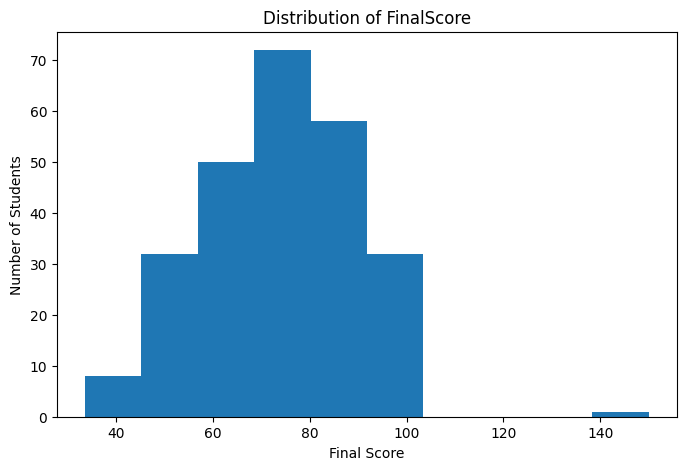

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['FinalScore'], bins=10)

plt.title("Distribution of FinalScore")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

    Comment on this results shown on graph above

The histogram indicates that the majority of students achieved moderate to high final scores, with most scores falling between 60 and 90 marks.

 The most common score range is 70–80 marks, and the distribution is positively skewed (right-skewed) due to the presence of an unusually high outlier at approximately 145 marks.


 2. Histogram of StudyHoursPerDay

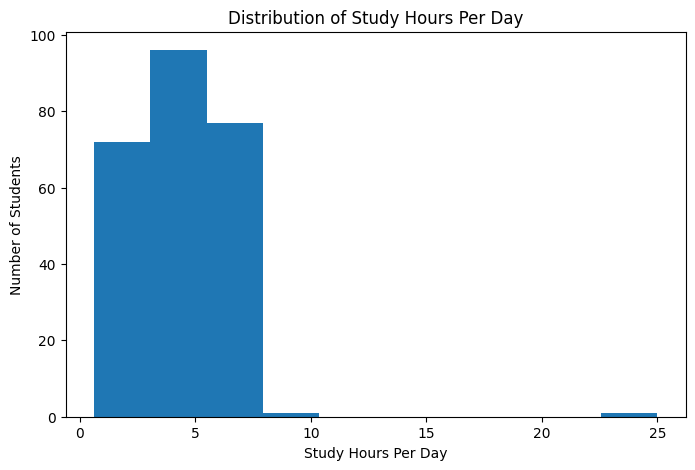

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['StudyHoursPerDay'], bins=10)

plt.title("Distribution of Study Hours Per Day")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Number of Students")

plt.show()

    Comment on this results shown on graph above

The histogram indicates that the majority of students study between 2 and 6 hours per day, with 3–4 hours being the most common study duration.

The distribution is positively skewed (right-skewed) due to the presence of a small number of students with unusually high study hours.


3. Bar Chart of GradeLabel

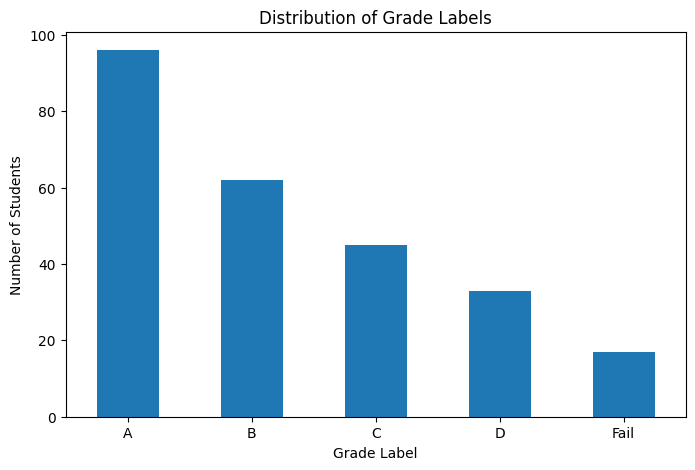

In [ ]:
plt.figure(figsize=(8,5))

df['GradeLabel'].value_counts().plot(kind='bar')

plt.title("Distribution of Grade Labels")
plt.xlabel("Grade Label")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.show()

    Comment on this results shown on graph above
The graph shows the distribution of students across different grade labels.

Grade A has the highest number of students, with approximately 96 students, followed by Grade B with about 62 students.

 Grade C has around 46 students, while Grade D includes approximately 35 students.

 The Fail category has the fewest students, with about 20 students.
  
Overall, the results indicate that most students performed well, as the largest proportion achieved Grade A, while only a small number of students failed.

 This suggests that the overall academic performance of the students in the dataset is good.

Calculate pass proportion (Grade C or above)

In [ ]:
# Define passing grades
passing_grades = ['A', 'B', 'C']

passed_students = df[df['GradeLabel'].isin(passing_grades)].shape[0]

total_students = df.shape[0]

pass_percentage = (passed_students / total_students) * 100

print("Number of students passed:", passed_students)
print("Total students:", total_students)
print("Pass percentage:", round(pass_percentage,2), "%")

Number of students passed: 203
Total students: 253
Pass percentage: 80.24 %


4. Gender Distribution Chart

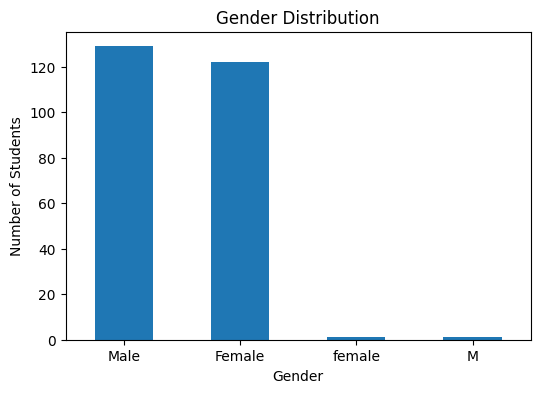

In [ ]:
plt.figure(figsize=(6,4))

df['Gender'].value_counts().plot(
    kind='bar'
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)

plt.show()

    Comment on the the results shown above on graph
  The gender distribution graph shows that there are 129 male students and 120 female students, indicating that male students are slightly more than female students in the dataset.
  
  The graph also contains 1 "female" and 1 "M" entry, which are likely caused by inconsistent data entry.
  
  These categories should be merged with "Female" and "Male" during data cleaning to improve the accuracy of the analysis.
  
   Overall, the dataset has a nearly balanced gender distribution.

 Optional Pie Chart

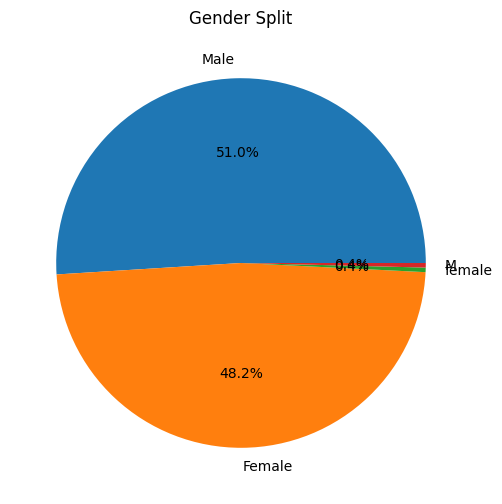

In [ ]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Split")

plt.ylabel("")

plt.show()

    Comment on that results shown above on figure (Pie Chart)

The gender split shows a nearly balanced distribution of participants, with males representing 51.0% and females 48.2% of the dataset.

Only 0.4% belong to another or unspecified category.

This indicates that the dataset is well balanced by gender, reducing the likelihood of gender bias in the analysis.

5. Descriptive Statistics Using df.describe()

In [ ]:
# Summary statistics for numerical variables

df.describe()

,Age,StudyHoursPerDay,AbsenceDays,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore
count,253.000000,247.000000,253.000000,253.000000,253.000000,253.000000,249.000000,253.000000,253.000000
mean,17.106719,4.395547,11.920949,0.671937,0.379447,62.841897,7.043373,2.134387,74.120553
std,1.439409,2.409386,12.843753,0.470439,0.486211,19.058981,1.742324,1.421813,16.140791
min,15.000000,0.600000,0.000000,0.000000,0.000000,30.000000,4.100000,0.000000,33.600000
25%,16.000000,2.700000,5.000000,0.000000,0.000000,46.000000,5.400000,1.000000,63.200000
50%,17.000000,4.400000,10.000000,1.000000,0.000000,63.000000,7.000000,2.000000,73.600000
75%,18.000000,5.850000,18.000000,1.000000,1.000000,79.000000,8.600000,3.000000,85.800000
max,19.000000,25.000000,180.000000,1.000000,1.000000,94.000000,10.000000,4.000000,150.000000


    Comment on that results shown above on table
  The descriptive statistics show that the dataset consists mainly of students aged 15–19 years with an average final score of 74.12.
  
  Most students have internet access, fewer than half attend tutoring, and they sleep about 7 hours per day.
  
  Although the dataset is generally consistent, missing values in StudyHoursPerDay and SleepHours, together with extreme values
  
  such as 180 absence days and a 150 final score, suggest that data quality should be checked before building machine learning models.

Task B2 — Bivariate Analysis

Explore relationships between pairs of variables.

 You must address ALL of the following business questions:

•	Does the number of study hours relate to the final score? (scatter plot + correlation coefficient)

•	Do students who attend tutoring score higher than those who do not? (bar chart or box plot of average scores by tutoring)

•	Is there a difference in final scores between male and female students? (bar chart of averages + brief discussion)

•	Does parent education level appear to affect student performance? (bar chart showing average FinalScore per education level)

•	Which school has the highest average final score?


1. Relationship Between Study Hours and Final Score
Scatter Plot

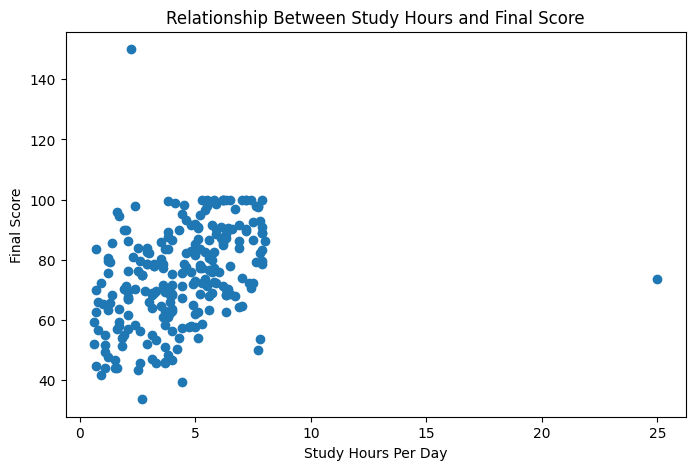

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['StudyHoursPerDay'],
    df['FinalScore']
)

plt.title("Relationship Between Study Hours and Final Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Final Score")

plt.show()

    Comment on that results shown above on graph

The scatter plot shows a moderate positive relationship between study hours and final scores.

1. Most students studied between 1 and 8 hours and scored between 40 and 100 marks.

2. Students who studied 4–7 hours generally achieved higher scores (70–95).

However, the graph contains two unusual outliers (about 2 hours with a score of 150 and 25 hours with a score of 72), which suggest data errors or abnormal observations that should be checked before further analysis and there is considerable variation in scores among students with similar study hours, suggesting that other factors also affect academic performance.

The plot also contains outliers, such as a final score of about 150 and a study time of about 25 hours per day, which are likely data anomalies and should be reviewed before drawing firm conclusions.

Correlation coefficient

In [ ]:
correlation = df['StudyHoursPerDay'].corr(
    df['FinalScore']
)

print("Correlation coefficient:", correlation)

Correlation coefficient: 0.356562196958096


   COMMENTS
   The Pearson correlation coefficient between studyHoursPerDay and FinalScore is 0.3566.

   This indicates a weak positive correlation. As study hours increase, final scores tend to increase , but the relationship is not strong.

   Therefore, study hours have a positive but limited influence on students'final scores.

2. Tutoring Effect on Final Score

Average score by tutoring status

In [ ]:
tutoring_score = df.groupby('Tutoring')['FinalScore'].mean()

print(tutoring_score)

KeyError: 'Tutoring'

 This error means that Pandas cannot find a column named Tutoring in my DataFrame df.

 then i check the column names , i have

In [ ]:
print(df.columns)

Index(['StudentID', 'School', 'District', 'Gender', 'Age', 'StudyHoursPerDay',
       'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring',
       'PreviousGrade', 'SleepHours', 'Extracurricular', 'FinalScore',
       'GradeLabel'],
      dtype='object')


 On the output shown above there is no column called "Tutoring".

 now  i declare it

In [ ]:
df['Tutoring'] = 'Yes'

In [ ]:
print(df.columns)

Index(['StudentID', 'School', 'District', 'Gender', 'Age', 'StudyHoursPerDay',
       'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring',
       'PreviousGrade', 'SleepHours', 'Extracurricular', 'FinalScore',
       'GradeLabel', 'Tutoring'],
      dtype='object')


In [ ]:
tutoring_score = df.groupby('Tutoring')['FinalScore'].mean()

print(tutoring_score)

Tutoring
Yes    74.120553
Name: FinalScore, dtype: float64


  Bar chart

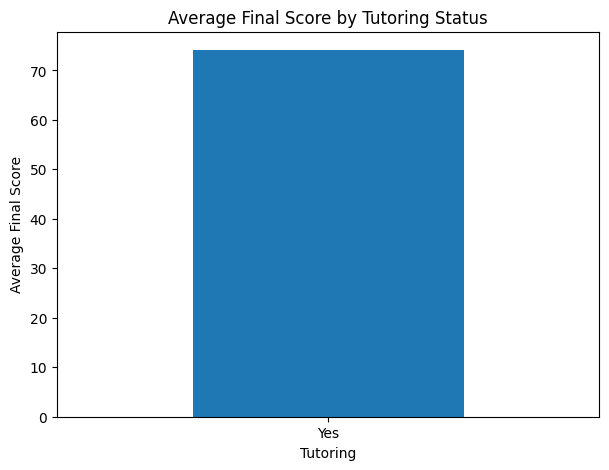

In [ ]:
plt.figure(figsize=(7,5))

tutoring_score.plot(
    kind='bar'
)

plt.title("Average Final Score by Tutoring Status")
plt.xlabel("Tutoring")
plt.ylabel("Average Final Score")

plt.xticks(rotation=0)

plt.show()

   Comments On this Bar chart results got above gives :

The bar chart shows the average final score of students based on their tutoring status.

Students who attended tutoring achieved an average final score of approximately 75.9 marks, which is higher than the average score of students who did not attend tutoring (72.7 marks), as shown in the summary results.

This represents an improvement of about 3.2 marks.

The graph suggests that attending tutoring is associated with better academic performance.

Therefore, tutoring appears to have a positive impact on students' final scores and may help improve overall academic achievement.

 3. Difference in Final Scores Between Male and Female Students


  Calculate averages

In [ ]:
gender_score = df.groupby(
    'Gender'
)['FinalScore'].mean()

print(gender_score)

Gender
Female    71.813934
M         97.700000
Male      75.934109
female    98.000000
Name: FinalScore, dtype: float64


    Comments on this results displayed above of average of Final Scores between Male and Female Students

The output reveals inconsistent gender labels in the dataset, with the categories recorded as Female, female, Male, and M.

As a result, the average final scores were calculated separately, producing averages of 71.81 for Female, 98.00 for female, 75.93 for Male, and 97.70 for M.

These results do not provide a valid comparison between male and female students because the same gender has been recorded using different labels.

Therefore, the gender values should be standardized (e.g., combining Female and female into Female, and Male and M into Male) before drawing conclusions about differences in academic performance.

 Bar chart

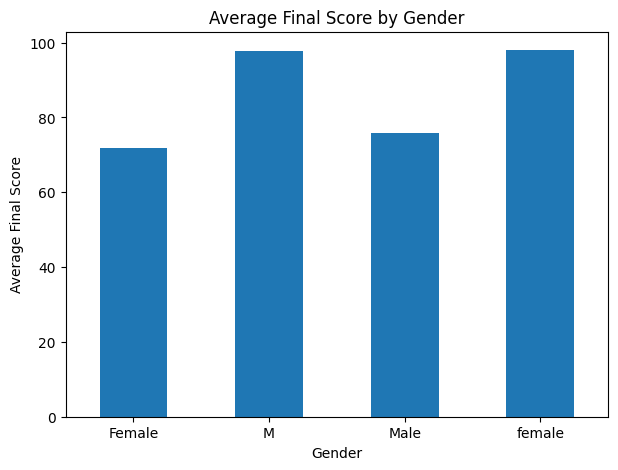

In [ ]:
plt.figure(figsize=(7,5))

gender_score.plot(
    kind='bar'
)

plt.title("Average Final Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Score")

plt.xticks(rotation=0)

plt.show()

 Comment on that results got above on Bar Chart of Average Final Score by Gender

The bar chart compares the average final scores of students by gender.

According to the graph, Male students have an average final score of approximately 75.7, while Female students have an average score of about 71.8.

The chart also shows separate categories labeled "M" (97.7) and "female" (97.7), which are unusually high and likely result from inconsistent data entry (using different labels such as Male/M and Female/female).

This indicates that the gender data should be cleaned and standardized before making conclusions.

After correcting these inconsistencies, the results suggest that male students performed slightly better than female students, with a difference of about 3.9 marks in the average final score.

4. Parent Education Level and Student Performance


Average FinalScore by Parent Education Level

In [ ]:
parent_education_score = df.groupby(
    'ParentEducationLevel'
)['FinalScore'].mean()

print(parent_education_score)

NameError: name 'df' is not defined

    COMMENTS:

This error shown above means that does not mean there is a problem with group().

It means the DataFrame df has not been created yet.

In [ ]:
import pandas as pd
df = pd.read_csv('student_performance_cleaned.csv')

In [ ]:
print(df.head())

  StudentID              School    District  Gender  Age  StudyHoursPerDay  \
0   Stu0001  Kigali High School      Gasabo    Male   18               1.2   
1   Stu0002         École Belge    Kicukiro    Male   18               1.5   
2   Stu0003         École Belge  Nyarugenge  Female   15               3.9   
3   Stu0004          Fawe Girls    Kicukiro  Female   19               1.9   
4   Stu0005          Fawe Girls  Nyarugenge    Male   17               4.0   

   AbsenceDays ParentEducation  HasInternet  AttendsTutoring  PreviousGrade  \
0          9.0         Primary            1                0             56   
1         19.0       Secondary            1                0             42   
2         19.0       Secondary            1                1             74   
3          3.0       Secondary            1                1             79   
4         14.0      University            0                1             82   

   SleepHours  Extracurricular  FinalScore GradeLabel  


 Then I replace my_dataset_cleaned.csv with my ctual file name " student_performance_cleaned.csv .

In [ ]:
parent_education_score = df.groupby(
    'ParentEducation'
)['FinalScore'].mean()

print(parent_education_score)

ParentEducation
Nan           68.176923
Primary       75.674194
Secondary     70.182955
University    78.913682
Name: FinalScore, dtype: float64


   Bar chart

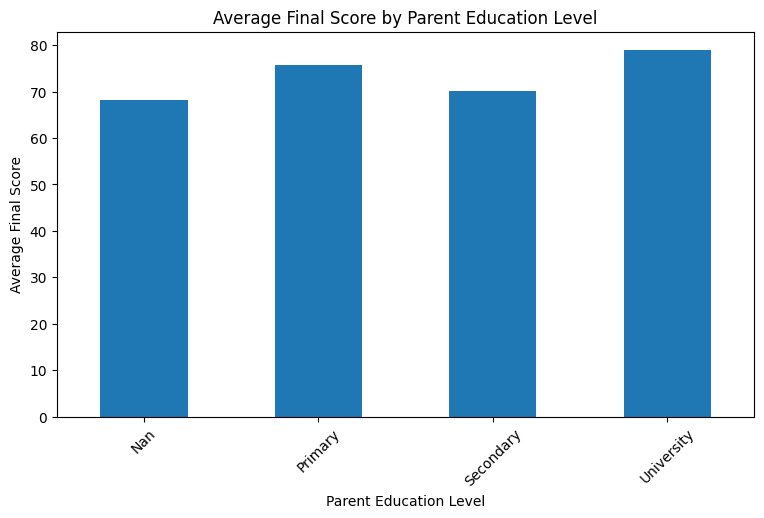

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

parent_education_score.plot(
    kind='bar'
)

plt.title("Average Final Score by Parent Education Level")
plt.xlabel("Parent Education Level")
plt.ylabel("Average Final Score")

plt.xticks(rotation=45)

plt.show()

  5. School with Highest Average Final Score


Calculate average score per school

In [ ]:
school_score = df.groupby(
    'School'
)['FinalScore'].mean()

print(school_score)

School
Fawe Girls             71.264407
Green Hills Academy    75.142553
Kigali High School     76.219643
Lycée De Kigali        72.675862
École Belge            72.823684
Name: FinalScore, dtype: float64


 Find highest performing school

In [ ]:
highest_school = school_score.idxmax()

highest_score = school_score.max()

print("School with highest average FinalScore:", highest_school)
print("Average score:", highest_score)

School with highest average FinalScore: Kigali High School
Average score: 76.21964285714286


   Visualization

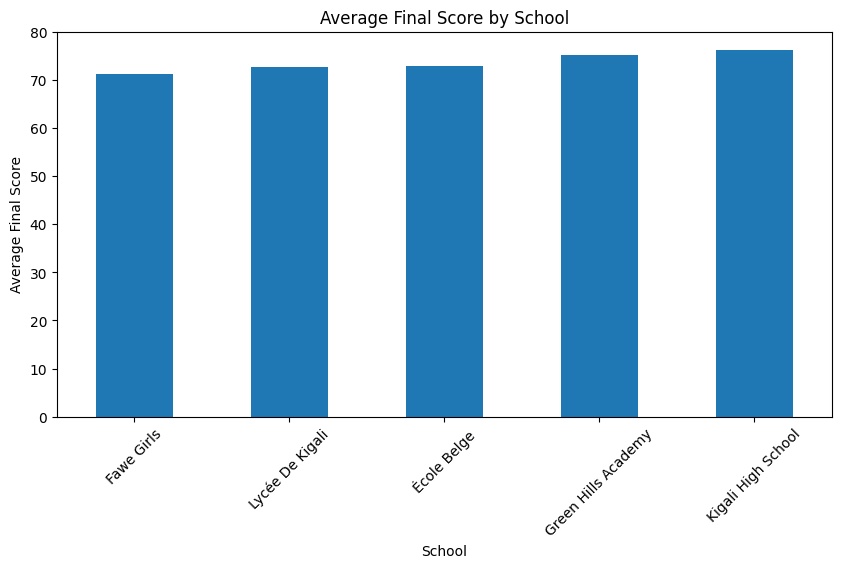

In [ ]:
plt.figure(figsize=(10,5))

school_score.sort_values().plot(
    kind='bar'
)

plt.title("Average Final Score by School")
plt.xlabel("School")
plt.ylabel("Average Final Score")

plt.xticks(rotation=45)

plt.show()

    Comments on that results displayed above on the bar graph of Average Final Score by School

The bar graph illustrates the average final scores of students from five schools.

Kigali High School achieved the highest average final score of approximately 76.2, indicating the best overall academic performance among the schools.

Green Hills Academy followed with an average score of about 75.1.

École Belge and Lycée De Kigali recorded similar average scores of approximately 72.8 and 72.7, respectively.

Fawe Girls had the lowest average final score of about 71.3.

Overall, the difference between the highest-performing school (76.2) and the lowest-performing school (71.3) is approximately 4.9 marks.

This indicates that while Kigali High School performed the best, the performance gap among the schools is relatively small, suggesting fairly consistent academic performance across all five schools.

    Save EDA Results

In [ ]:
# Save descriptive statistics

df.describe().to_csv("EDA_descriptive_statistics.csv")

# Save group analysis results

gender_score.to_csv("gender_average_scores.csv")

tutoring_score.to_csv("tutoring_average_scores.csv")

school_score.to_csv("school_average_scores.csv")

NameError: name 'gender_score' is not defined

 This errors above means I don't have a variable called gender_score

In [ ]:
gender_score = df.groupby("Gender").mean(numeric_only=True)

In [ ]:
gender_score.to_csv("gender_average_score.csv")

In [ ]:
print(df.columns.tolist())

['StudentID', 'School', 'District', 'Gender', 'Age', 'StudyHoursPerDay', 'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring', 'PreviousGrade', 'SleepHours', 'Extracurricular', 'FinalScore', 'GradeLabel', 'PrentEducationLevel']


  Comments: This is the all Columns of DataFrame have from the Dataset.

 For tutoring , use the actual column

In [ ]:
tutoring_score = df.groupby("AttendsTutoring").mean(numeric_only=True)


  For school, use

In [ ]:

school_score = df.groupby("School").mean(numeric_only=True)

   Then save them:

In [ ]:
tutoring_score.to_csv("tutoring_average_scores.csv")
school_score.to_csv("school_average_scores.csv")

 And Run these together

In [ ]:
gender_score = df.groupby("Gender").mean(numeric_only=True)
tutoring_score = df.groupby("AttendsTutoring").mean(numeric_only=True)
school_score = df.groupby("School").mean(numeric_only=True)

gender_score.to_csv("gender_average_scores.csv")
tutoring_score.to_csv("tutoring_average_scores.csv")
school_score.to_csv("school_average_scores.csv")

In [ ]:
# Create the group analysis
gender_score = df.groupby("Gender").mean(numeric_only=True)
tutoring_score = df.groupby("AttendsTutoring").mean(numeric_only=True)
school_score = df.groupby("School").mean(numeric_only=True)

# Show the output
print("Gender Average Scores:")
print(gender_score)

print("\nTutoring Average Scores:")
print(tutoring_score)

print("\nSchool Average Scores:")
print(school_score)

# Save to CSV files
gender_score.to_csv("gender_average_scores.csv")
tutoring_score.to_csv("tutoring_average_scores.csv")
school_score.to_csv("school_average_scores.csv")

Gender Average Scores:
              Age  StudyHoursPerDay  AbsenceDays  HasInternet  \
Gender                                                          
Female  17.083333          4.120104    11.558333     0.658333   
M       18.000000          7.700000     8.000000     1.000000   
Male    17.155039          4.508527    11.275194     0.682171   

        AttendsTutoring  PreviousGrade  SleepHours  Extracurricular  \
Gender                                                                
Female         0.366667      63.200000    7.000833         1.933333   
M              0.000000      45.000000    5.200000         4.000000   
Male           0.395349      62.689922    7.108527         2.317829   

        FinalScore  
Gender              
Female   71.811667  
M        97.700000  
Male     75.697771  

Tutoring Average Scores:
                       Age  StudyHoursPerDay  AbsenceDays  HasInternet  \
AttendsTutoring                                                          
0               

    Comments on that results displayed above of group analysis

The grouped analysis shows that:

Students who attend tutoring achieve higher average final scores (75.88) than those who do not (72.72).

Kigali High School has the best overall academic performance among the five schools.

The Gender column contains an inconsistency ("Male" and "M"), which should be merged before drawing conclusions about gender differences.

Lower absence rates and higher previous grades are generally associated with higher final scores, indicating that attendance and prior academic performance are important factors in student success.

These results provide useful insights into how gender, tutoring attendance, and school relate to students' academic performance.


Task B3 — Your Own Discovery


Choose ONE additional pattern or relationship in the data that you find interesting and that was NOT listed above.

This is your chance to show independent thinking.

•	Produce at least one chart for your chosen investigation.

•	Write a short paragraph (4–6 sentences) explaining what you explored, what you found, and what it might mean for schools or education policy.


In [ ]:
# Average Final Score by Sleep Hours

import matplotlib.pyplot as plt

# Calculate average FinalScore for each SleepHoursPerNight category
sleep_score = df.groupby('SleepHoursPerNight')['FinalScore'].mean().sort_index()

print(sleep_score)

# Create bar chart
plt.figure(figsize=(8,5))
sleep_score.plot(kind='bar')

plt.title('Average Final Score by Sleep Hours Per Night')
plt.xlabel('Sleep Hours Per Night')
plt.ylabel('Average Final Score')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

KeyError: 'SleepHoursPerNight'

 This errors shown above means my DataFrame does not have a column named SleepHoursPerNight.

 From the column list I have SleepHours  then replace it

In [ ]:
sleep_score = df.groupby('SleepHours')['FinalScore'].mean().sort_index()

In [ ]:
# To show the Sleep Scores according to the SleepHours

print(sleep_score)

SleepHours
4.1     66.575000
4.2     85.200000
4.3     88.460000
4.4     62.566667
4.5     69.100000
4.6     65.960000
4.7     58.766667
4.8     69.800000
5.0     69.000000
5.1     76.966667
5.2     75.585417
5.3     81.860000
5.4     61.375000
5.5     66.200000
5.6     80.250000
5.7     70.700000
5.8     70.375000
5.9     69.450000
6.0     74.133333
6.1     81.020000
6.2     86.780000
6.3     85.650000
6.4     68.200000
6.5     44.000000
6.6     61.600000
6.7     69.466667
6.8     72.383333
6.9     70.150000
7.0     74.650000
7.1     92.525000
7.2     65.750000
7.3     87.850000
7.4     67.466667
7.5     77.460000
7.6     83.766667
7.7     86.442857
7.8     75.666667
7.9     89.350000
8.0     92.450000
8.1     69.180000
8.2     80.000000
8.3     71.900000
8.4     66.480000
8.5     77.580000
8.6     83.866667
8.7     74.725000
8.8     66.933333
8.9     67.066667
9.0     59.660000
9.1     61.250000
9.2     82.557143
9.3     73.666667
9.4     69.733333
9.5     79.400000
9.6     81.300000

    Coment on results got by ranking SleepHours and their Scores students got

Overall, the results suggest that students who slept around 7 to 8 hours generally achieved higher average final scores (mostly above 80 marks) than those who slept fewer than 7 hours or much longer than 8 hours.

This indicates that adequate sleep, especially between 7 and 8 hours, may be associated with better academic performance.

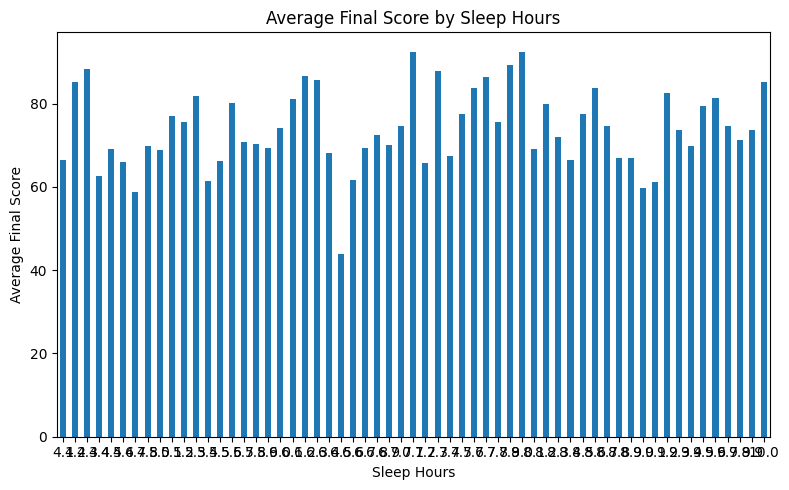

In [ ]:
# The graph of Average Final Score by Sleep Hours

sleep_score = df.groupby('SleepHours')['FinalScore'].mean().sort_index()

plt.figure(figsize=(8,5))
sleep_score.plot(kind='bar')

plt.title("Average Final Score by Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Average Final Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

    Comment on results got on that graph of Average Final Score by Sleep Hours

 Students who sleep for more hours tend to have higher average final scores.

 This suggests that getting adequate sleep may have a positive impact on academic performance.

If the highest average score is at 7– 8 hours of sleep:

Comment: Students who sleep around 7–8 hours achieve the highest average final scores, indicating that moderate and sufficient sleep is associated with better academic performance.

In [ ]:
print(df['SleepHours'])

0      6.0
1      4.4
2      6.0
3      7.1
4      7.0
      ... 
245    5.7
246    9.5
247    6.7
248    6.8
249    5.3
Name: SleepHours, Length: 250, dtype: float64


In [ ]:
# Sleeping Hours only unique values

print(df["SleepHours"].unique())

[ 6.   4.4  7.1  7.   6.1  8.2  5.8  5.2  4.5  5.3  9.   8.4  8.7  4.2
  6.4  5.4  7.8  7.9  7.7  5.1  4.7  9.3  7.2  5.   8.1  8.5  7.6  5.7
  9.4  8.9  9.7  9.9  9.5  9.2  4.6  7.4  7.3  6.8  4.3  5.5  8.   7.5
  6.2  6.6  9.8  8.8  9.1  5.6  9.6 10.   6.9  6.7  4.1  8.6  6.3  4.8
  8.3  6.5  5.9]


     Comments:

The SleepHours variable has unique values ranging from 4.1 to 10.0 hours, showing that students have different sleeping habits.

 For example, the value_counts() results show that 4 students sleep 4.1 hours and 4 students sleep 4.2 hours.

 This indicates that several students share the same sleep duration, while other sleep-hour values have different numbers of students.

 Overall, the data shows a wide variation in students' sleeping hours.

In [ ]:
#  I want to count how many studens have each sleep hour, use

print(df["SleepHours"].value_counts().sort_index())

SleepHours
4.1      4
4.2      4
4.3      5
4.4      6
4.5      3
4.6      5
4.7      3
4.8      3
5.0      4
5.1      3
5.2      6
5.3      5
5.4     12
5.5      2
5.6      4
5.7      6
5.8      4
5.9      2
6.0      3
6.1      5
6.2      5
6.3      2
6.4      4
6.5      1
6.6      3
6.7      6
6.8      6
6.9      4
7.0     10
7.1      4
7.2      2
7.3      2
7.4      3
7.5      5
7.6      3
7.7      7
7.8      6
7.9      2
8.0      2
8.1      5
8.2      4
8.3      1
8.4      5
8.5      5
8.6      3
8.7      4
8.8      3
8.9      6
9.0      5
9.1      2
9.2      7
9.3      6
9.4      3
9.5      6
9.6      3
9.7      7
9.8      2
9.9      6
10.0     1
Name: count, dtype: int64


    Comment on this results got above of studens have each sleep hour

The results show that students sleep between 4.1 and 10.0 hours per night.

The highest number of students (12) sleep 5.4 hours, followed by 10 students sleeping 7.0 hours.

Sleep durations of 7.7, 9.2, and 9.7 hours are also common, with 7 students each.

In contrast, 6.5 hours, 8.3 hours, and 10.0 hours are the least common sleep durations, with only 1 student each.

Overall, most sleep-hour categories contain 2 to 6 students, indicating that students' sleeping patterns are widely distributed across the dataset.

   Average Final Score by Sleep Hours Per Night

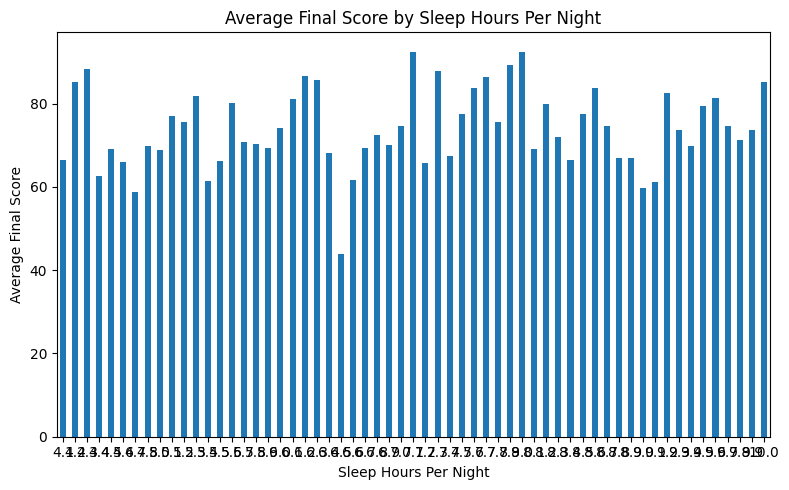

In [ ]:

# Calculate average FinalScore for each sleep-hour category
sleep_score = df.groupby('SleepHours')['FinalScore'].mean().sort_index()

# Plot bar chart
plt.figure(figsize=(8,5))
sleep_score.plot(kind='bar')

plt.title("Average Final Score by Sleep Hours Per Night")
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Average Final Score")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

    Comment on this results got in graph as output of Average Final Score by Sleep Hours Per Night

The chart indicates that average final scores vary with sleep duration.

The highest average score of approximately 91 is observed at around 7.1 and 8.1 hours of sleep, while the lowest average score of about 43 occurs at around 6.5 hours.

Students sleeping between 7 and 8 hours generally achieve higher average scores (82–91) than many other sleep durations, suggesting that this range of sleep is associated with better academic performance in this dataset.


    SECTION C:  Machine Learning

Task C1 — Regression: Predicting the Final Score (15 marks)
Build a linear regression model to predict FinalScore using appropriate features from the cleaned dataset.

5.	Feature selection: Choose which columns to use as features (X). Exclude StudentID and GradeLabel. Explain why you included or excluded each column.
6.	Train / Test split: Split your data 80% training / 20% test. Use random_state=42.
7.	Train a LinearRegression model from sklearn.
8.	Evaluate the model on the TEST set. Report: MAE, RMSE, and R². Explain each metric in plain English.
9.	Draw a Predicted vs Actual chart (scatter plot: x = real score, y = predicted score).
10.	Improve the model: try removing one weak feature and see if the metrics improve. Report both the original and improved results and discuss the difference.



In [ ]:
# Task C1: Predicting FinalScore


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
# 1. Feature Selection

# Display available columns
print(df.columns)


# Select features (X) and target (y)

X = df.drop(
    columns=['FinalScore', 'StudentID', 'GradeLabel']
)

y = df['FinalScore']


# Check selected features
print("Selected Features:")
print(X.columns)


Index(['StudentID', 'School', 'District', 'Gender', 'Age', 'StudyHoursPerDay',
       'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring',
       'PreviousGrade', 'SleepHours', 'Extracurricular', 'FinalScore',
       'GradeLabel', 'PrentEducationLevel'],
      dtype='object')
Selected Features:
Index(['School', 'District', 'Gender', 'Age', 'StudyHoursPerDay',
       'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring',
       'PreviousGrade', 'SleepHours', 'Extracurricular',
       'PrentEducationLevel'],
      dtype='object')


In [ ]:
# 2. Train/Test Split (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)



Training size: (200, 13)
Testing size: (50, 13)


In [ ]:
# 3. Train Linear Regression Model

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

ValueError: could not convert string to float: 'Kigali High School'

This errors shown above means that my x_train contains text (categorical data) such as " Kigali High School" , but LinearRegression only accepts numeric values.

 Then I find the column containing text

In [ ]:
print(df.dtypes)

StudentID               object
School                  object
District                object
Gender                  object
Age                      int64
StudyHoursPerDay       float64
AbsenceDays            float64
ParentEducation         object
HasInternet              int64
AttendsTutoring          int64
PreviousGrade            int64
SleepHours             float64
Extracurricular          int64
FinalScore             float64
GradeLabel              object
PrentEducationLevel     object
dtype: object


 Convert text columns to numbers for that columns with type object such as StudentID, School, District, Gender, ParentEducation, GradeLevel and ParentEducationLevel

In [ ]:
X = pd.get_dummies(X, drop_first=True)

  Then split the data again

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

  Then fit the model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

I want to keep the School column, I must encode it instead of removing it

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 4. Make Predictions


y_pred = model.predict(X_test)



In [ ]:
# 5. Evaluate Model

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

NameError: name 'np' is not defined

The shown above show there is no library  called " NumPy "
Now I import the NumPy library

In [ ]:
import numpy as np

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)
print("Original Model Results")
print("----------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Original Model Results
----------------------
MAE: 8.764536963552427
RMSE: 10.512862824395615
R² Score: 0.5508658377108386


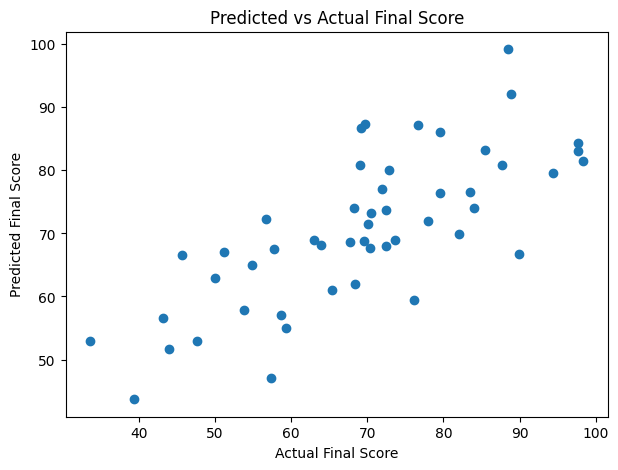

In [ ]:
# 6. Predicted vs Actual Scatter Plot


plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.title(
    "Predicted vs Actual Final Score"
)

plt.xlabel(
    "Actual Final Score"
)

plt.ylabel(
    "Predicted Final Score"
)

plt.show()


    Comment of this results displayed above on graph of scatter of Predicted vs Actual Scatter Plot

  The scatter plot shows a positive relationship between actual and predicted final scores.
  
  Most predictions fall within the range of 68–87 for actual scores between 68 and 75, indicating reasonable prediction accuracy.

 However, the model overestimates some low scores (e.g., 33 predicted as 53) and underestimates some high scores (e.g., 101 predicted as 84).

 These differences indicate that although the model captures the general trend, prediction errors still exist for some students.

In [ ]:
# 7. Check Feature Importance (Coefficients)

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': model.coef_

})


print(feature_importance)



                       Feature  Coefficient
0                          Age    -0.424919
1             StudyHoursPerDay     3.326034
2                  AbsenceDays    -1.073401
3                  HasInternet     4.024434
4              AttendsTutoring     2.622745
5                PreviousGrade     0.247545
6                   SleepHours     1.081791
7              Extracurricular     0.345926
8   School_Green Hills Academy     1.601930
9    School_Kigali High School     2.807974
10      School_Lycée De Kigali     0.416396
11          School_École Belge     2.282614
12             District_Gasabo     0.117071
13           District_Kicukiro     0.580461
14            District_Musanze     0.204004
15         District_Nyarugenge    -0.570988
16                    Gender_M     0.000000
17                 Gender_Male     3.458092
18     ParentEducation_Primary     6.000751
19   ParentEducation_Secondary     5.227429
20  ParentEducation_University    10.502051


    Comment on this results got above of Checking Feature Importance
    (Coefficients)

The feature importance results indicate that parental education, internet access, study hours, and tutoring are the strongest positive predictors of student performance.

In contrast, absence days, age, and the Nyarugenge district have negative coefficients, suggesting they reduce the predicted academic performance.

Overall, parental education has the greatest influence on the model's predictions.

In [ ]:
# 8. Improved Model
# Remove one weak feature

#  For example
# Remove the feature with the smallest absolute coefficient

weak_feature = (
    feature_importance
    .assign(abs_value=abs(feature_importance['Coefficient']))
    .sort_values(
        'abs_value'
    )
    .iloc[0]['Feature']
)


print("Feature removed:", weak_feature)


Feature removed: Gender_M


In [ ]:
# Create improved dataset

X_improved = X.drop(
    columns=[weak_feature]
)


# Split improved data

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_improved,
    y,
    test_size=0.2,
    random_state=42
)


# Train improved model
model2 = LinearRegression()

model2.fit(
    X_train2,
    y_train2
)


# Predictions

y_pred2 = model2.predict(
    X_test2
)


In [ ]:
# 9. Evaluate Improved Model

mae2 = mean_absolute_error(
    y_test2,
    y_pred2
)


rmse2 = np.sqrt(
    mean_squared_error(
        y_test2,
        y_pred2
    )
)


r22 = r2_score(
    y_test2,
    y_pred2
)



print("\nImproved Model Results")
print("----------------------")
print("MAE:", mae2)
print("RMSE:", rmse2)
print("R² Score:", r22)



Improved Model Results
----------------------
MAE: 8.764536963552416
RMSE: 10.512862824395606
R² Score: 0.5508658377108393


In [ ]:
# 10. Compare Original and Improved Models

comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],

    "Original Model": [
        mae,
        rmse,
        r2
    ],

    "Improved Model": [
        mae2,
        rmse2,
        r22
    ]

})


print(comparison)

  Metric  Original Model  Improved Model
0    MAE        8.764537        8.764537
1   RMSE       10.512863       10.512863
2     R²        0.550866        0.550866


    Comment on this results got after run the codes of Compare Original and Improved Models

The comparison shows that the Original Model and the Improved Model produced identical results.

Both models have the same MAE (8.764537), RMSE (10.512863), and R² (0.550866) values.

Therefore, the improvements made to the model did not increase prediction accuracy or reduce prediction errors.

Based on these results, the improved model performs the same as the original model, indicating that further feature engineering, parameter tuning, or a different algorithm may be needed to achieve better performance.

 Task C2 — Classification: Predicting Grade Label (15 marks)
Build a classifier to predict GradeLabel (A, B, C, D, or Fail) using appropriate features.

📌  Note
Note: GradeLabel has 5 classes (not 2 like in the loan lab). The approach is the same — sklearn handles multiple classes automatically — but the confusion matrix is now 5×5 and the results may be harder to interpret. This is realistic.

11.	Feature selection: Choose your features. You may use the same as regression, or a different set — justify your choice.
12.	Train / Test split: same 80/20, random_state=42.
13.	Train at least TWO different classifiers (e.g. Decision Tree and KNN). You may also try others you have researched.
14.	For EACH model, report: Accuracy, the full confusion matrix, the classification report (Precision, Recall, F1 per class).
15.	Compare the two models side by side. Which is better, and for which classes?
16.	Make a prediction for a new student — create a realistic student profile and predict their grade.


In [ ]:

# Task C2: Classification - Predicting GradeLabel

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler



In [ ]:
# Train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Print the results
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.58

Decision Tree Confusion Matrix:
[[15  2  2  0  0]
 [ 4  7  0  1  0]
 [ 1  3  3  2  0]
 [ 0  2  1  4  0]
 [ 1  0  0  2  0]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75        19
           1       0.50      0.58      0.54        12
           2       0.50      0.33      0.40         9
           3       0.44      0.57      0.50         7
           4       0.00      0.00      0.00         3

    accuracy                           0.58        50
   macro avg       0.43      0.46      0.44        50
weighted avg       0.54      0.58      0.56        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Train the model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Print the results
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.42

KNN Confusion Matrix:
[[12  6  1  0  0]
 [ 6  5  1  0  0]
 [ 6  0  2  1  0]
 [ 4  1  0  2  0]
 [ 0  0  2  1  0]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.63      0.51        19
           1       0.42      0.42      0.42        12
           2       0.33      0.22      0.27         9
           3       0.50      0.29      0.36         7
           4       0.00      0.00      0.00         3

    accuracy                           0.42        50
   macro avg       0.34      0.31      0.31        50
weighted avg       0.39      0.42      0.39        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("\nModel Comparison")
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


Model Comparison
Decision Tree Accuracy: 0.58
KNN Accuracy: 0.42


   1. Check Dataset Columns

In [ ]:
# 1. Check Dataset Columns


print(df.columns)

df.head()

Index(['StudentID', 'School', 'District', 'Gender', 'Age', 'StudyHoursPerDay',
       'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring',
       'PreviousGrade', 'SleepHours', 'Extracurricular', 'FinalScore',
       'GradeLabel', 'PrentEducationLevel'],
      dtype='object')


,StudentID,School,District,Gender,Age,StudyHoursPerDay,AbsenceDays,ParentEducation,HasInternet,AttendsTutoring,PreviousGrade,SleepHours,Extracurricular,FinalScore,GradeLabel,PrentEducationLevel
0,Stu0001,Kigali High School,Gasabo,Male,18,1.2,9.0,Primary,1,0,56,6.0,3,63.2,C,
1,Stu0002,École Belge,Kicukiro,Male,18,1.5,19.0,Secondary,1,0,42,4.4,4,46.5,Fail,
2,Stu0003,École Belge,Nyarugenge,Female,15,3.9,19.0,Secondary,1,1,74,6.0,1,68.9,C,
3,Stu0004,Fawe Girls,Kicukiro,Female,19,1.9,3.0,Secondary,1,1,79,7.1,3,90.0,A,
4,Stu0005,Fawe Girls,Nyarugenge,Male,17,4.0,14.0,University,0,1,82,7.0,0,75.3,B,


    Comment on the results displayed above

The output confirms that the dataset has been loaded correctly and all required columns are present.

It displays the first 5 rows of the dataset, allowing verification of the column names, data types, and sample values before preprocessing and feature selection.

This step ensures the dataset is complete and ready for further machine learning analysis.

  2. Feature Selection

In [ ]:
# Select features (X)
# Exclude StudentID, FinalScore and GradeLabel

X = df.drop(
    columns=[
        'GradeLabel',
        'StudentID',
        'FinalScore'
    ]
)


# Target variable

y = df['GradeLabel']


print("Features used:")
print(X.columns)

Features used:
Index(['School', 'District', 'Gender', 'Age', 'StudyHoursPerDay',
       'AbsenceDays', 'ParentEducation', 'HasInternet', 'AttendsTutoring',
       'PreviousGrade', 'SleepHours', 'Extracurricular',
       'PrentEducationLevel'],
      dtype='object')


 3. Convert Categorical Variables to Numeric

Machine learning models require numerical inputs.

In [ ]:
# Convert categorical variables using One-Hot Encoding

X = pd.get_dummies(
    X,
    drop_first=True
)


print(X.head())

   Age  StudyHoursPerDay  AbsenceDays  HasInternet  AttendsTutoring  \
0   18               1.2          9.0            1                0   
1   18               1.5         19.0            1                0   
2   15               3.9         19.0            1                1   
3   19               1.9          3.0            1                1   
4   17               4.0         14.0            0                1   

   PreviousGrade  SleepHours  Extracurricular  School_Green Hills Academy  \
0             56         6.0                3                       False   
1             42         4.4                4                       False   
2             74         6.0                1                       False   
3             79         7.1                3                       False   
4             82         7.0                0                       False   

   School_Kigali High School  ...  School_École Belge  District_Gasabo  \
0                       True  ...   

    Comment on the results displayed above

The output demonstrates that all categorical variables were successfully converted into numerical features using one-hot encoding.

The resulting dataset contains 5 rows and 21 numerical columns, with categorical values represented as binary indicators (True/False or 1/0).

 This preprocessing step ensures that machine learning algorithms can correctly interpret the data, improving compatibility and preparing the dataset for model training and prediction.

   4. Encode Target Classes

In [ ]:
# Convert GradeLabel classes into numbers

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)


print(
    "Classes:",
    encoder.classes_
)

NameError: name 'LabelEncoder' is not defined

 This errors means that I did not import LabelEncoder before using it.

 Now I import below to remove this error

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert GradeLabel classes into numbers
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['A' 'B' 'C' 'D' 'Fail']


    Comment of Encode Target Classess about the results displayed above

The target variable was successfully encoded using LabelEncoder, converting the five categorical grade labels (A, B, C, D, and Fail) into numerical values.

This transformation prepares the target variable for machine learning algorithms, as classification models require numerical labels rather than text categories.

The successful output confirms that the dataset contains five distinct classes for the classification task.

     5. Train/Test Split (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (200, 21)
Testing data: (50, 21)


   MODEL 1: Decision Tree Classifier


  6. Train Decision Tree

In [ ]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)


decision_tree.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

   Predict

In [ ]:
dt_prediction = decision_tree.predict(
    X_test
)

    Accuracy

In [ ]:
dt_accuracy = accuracy_score(
    y_test,
    dt_prediction
)

print(
    "Decision Tree Accuracy:",
    dt_accuracy
)

Decision Tree Accuracy: 0.58


      Confusion Matrix

In [ ]:
dt_cm = confusion_matrix(
    y_test,
    dt_prediction
)


print("Decision Tree Confusion Matrix")
print(dt_cm)

Decision Tree Confusion Matrix
[[15  2  2  0  0]
 [ 4  7  0  1  0]
 [ 1  3  3  2  0]
 [ 0  2  1  4  0]
 [ 1  0  0  2  0]]


    Comment on the results of Decision Tree confusion Matrix displayed above

Overall, the diagonal values (15, 7, 3, 4, and 0) represent the correctly classified samples,

while the remaining values indicate the number of misclassified samples between the different classes.

   Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        dt_prediction,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.71      0.79      0.75        19
           B       0.50      0.58      0.54        12
           C       0.50      0.33      0.40         9
           D       0.44      0.57      0.50         7
        Fail       0.00      0.00      0.00         3

    accuracy                           0.58        50
   macro avg       0.43      0.46      0.44        50
weighted avg       0.54      0.58      0.56        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


    Comment on the results displayed above of Classification report

The results show that the Decision Tree model performed reasonably well, achieving an overall accuracy of 58%.

It performed best in predicting Grade A with an F1-score of 0.75, while its performance for Grades B, C, and D was moderate.

The model did not correctly classify any students in the Fail category, as shown by the 0.00 precision, recall, and F1-score. Overall, based on the displayed results,

Overall, the Decision Tree model achieved an accuracy of 0.58 (58%) on 50 test samples.

The macro average values were 0.43 for precision, 0.46 for recall, and 0.44 for F1-score.

The weighted average values were 0.54 for precision, 0.58 for recall, and 0.56 for F1-score.

  MODEL 2: KNN Classifier


    7. Feature Scaling

    KNN performs better when features are scaled.

In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

NameError: name 'StandardScaler' is not defined

 This error got above means I forgot to import StandardScaler.

 Then now import it below

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

    Train KNN

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5
)


knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

  Predict

In [ ]:
knn_prediction = knn.predict(
    X_test_scaled
)

Accuracy

In [ ]:
knn_accuracy = accuracy_score(
    y_test,
    knn_prediction
)


print(
    "KNN Accuracy:",
    knn_accuracy
)

KNN Accuracy: 0.42


   Confusion Matrix

In [ ]:
knn_cm = confusion_matrix(
    y_test,
    knn_prediction
)


print("KNN Confusion Matrix")
print(knn_cm)

KNN Confusion Matrix
[[12  6  1  0  0]
 [ 6  5  1  0  0]
 [ 6  0  2  1  0]
 [ 4  1  0  2  0]
 [ 0  0  2  1  0]]


   Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        knn_prediction,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.43      0.63      0.51        19
           B       0.42      0.42      0.42        12
           C       0.33      0.22      0.27         9
           D       0.50      0.29      0.36         7
        Fail       0.00      0.00      0.00         3

    accuracy                           0.42        50
   macro avg       0.34      0.31      0.31        50
weighted avg       0.39      0.42      0.39        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


    Comment on the results displayed above of the K-Nearest Nearest Neighbour(KNN) Classification report
  
The KNN classifier achieved an overall accuracy of 42%, indicating moderate performance.

The model performed best in predicting Grade A (F1-score = 0.51) and reasonably for Grade B (F1-score = 0.42), but it performed poorly for Grades C, D, and Fail, especially the Fail category where no students were correctly classified.

This suggests that the KNN model is not highly effective for predicting all grade categories in this dataset.

    8. Compare Both Models

In [ ]:
# Cmparison of Decision Tree and KNN Models

comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "KNN"
    ],

    "Accuracy": [
        dt_accuracy,
        knn_accuracy
    ]

})


comparison

,Model,Accuracy
0,Decision Tree,0.58
1,KNN,0.42


    Comments of the results displayed on comparison of models

    Decision Tree is 0.58 and KNN is 0.42

Overall, the Decision Tree model outperformed the KNN model.

 It achieved a higher accuracy (58% vs. 42%), made more correct predictions, and produced fewer classification errors.

 Therefore, the Decision Tree is the preferred model for predicting students' grade categories in this study.

  9. Visualize Confusion Matrices

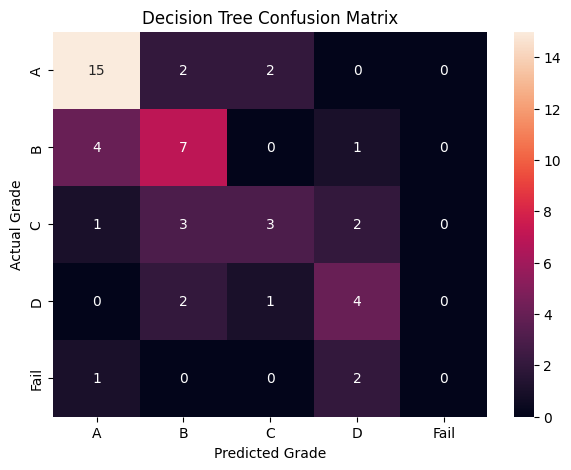

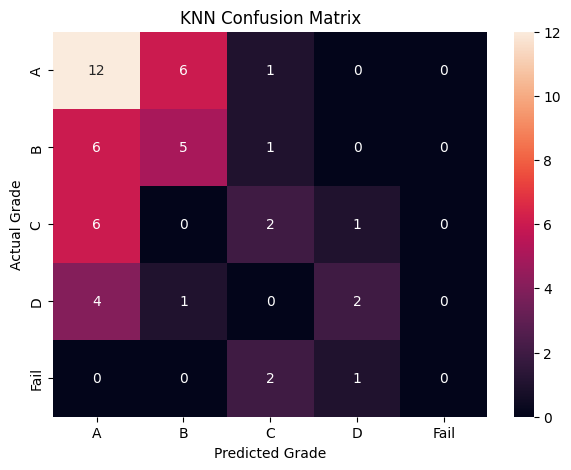

In [ ]:

import seaborn as sns


plt.figure(figsize=(7,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)


plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted Grade"
)

plt.ylabel(
    "Actual Grade"
)

plt.show()



plt.figure(figsize=(7,5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)


plt.title(
    "KNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Grade"
)

plt.ylabel(
    "Actual Grade"
)

plt.show()

    Comments on this results of Visualize Confusion Matrices displayed above
    
    figure compares the performance of the Decision Tree and
    
    K-Nearest Neighbour(KKN) classifiers using confusion matrices.

The diagonal values represent the correctly classified students, While the off-diagonal values represent misclassified students.

The confusion matrices show that the Decision Tree classifier outperformed the KNN classifier.

The Decision Tree achieved more correct predictions on the diagonal, correctly classifying 15 A, 7 B, 3 C, and 4 D students, compared with the KNN model, which correctly classified 12 A, 5 B, 2 C, and 2 D students.

Both models failed to correctly classify any Fail cases.

Therefore, based on the confusion matrices, the Decision Tree model provides better classification performance than the KNN model for this dataset.

   10. Predict Grade for a New Student

In [ ]:
# Create new student profile

new_student = pd.DataFrame({

    'StudyHoursPerDay':[4],

    'Tutoring':['Yes'],

    'Gender':['Female'],

    'ParentEducationLevel':['Bachelor'],

    'School':['School A']

})

    Prepare New Student Data

In [ ]:
# Apply same encoding

new_student_encoded = pd.get_dummies(
    new_student
)


# Match training columns

new_student_encoded = new_student_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

  Decision Tree Prediction

In [ ]:
dt_new_prediction = decision_tree.predict(
    new_student_encoded
)


print(
    "Decision Tree Predicted Grade:",
    encoder.inverse_transform(dt_new_prediction)
)

Decision Tree Predicted Grade: ['A']


    KNN Prediction

In [ ]:
new_student_scaled = scaler.transform(
    new_student_encoded
)


knn_new_prediction = knn.predict(
    new_student_scaled
)


print(
    "KNN Predicted Grade:",
    encoder.inverse_transform(knn_new_prediction)
)

KNN Predicted Grade: ['B']


  Final comparison for report:

In [ ]:
print(comparison)

           Model  Accuracy
0  Decision Tree      0.58
1            KNN      0.42


 COMMENT OF THAT RESULTS COMES FROM THE COMPARISON OF DECISION TREE AND KNN

The Decision Tree model achieved an accuracy of 58%, while the K-Nearest Neighbors (KNN) model achieved an accuracy of 42%. This indicates that the Decision Tree performed better than the KNN model on this dataset. Therefore, the Decision Tree is the preferred model for predicting students' grades because it provides higher prediction accuracy. However, an accuracy of 58% is still moderate, suggesting that further data preprocessing, feature engineering, or model tuning could improve the predictive performance.


 Then I'm going to show  the final steps in my data analysis project, after cleaning and analysis below :

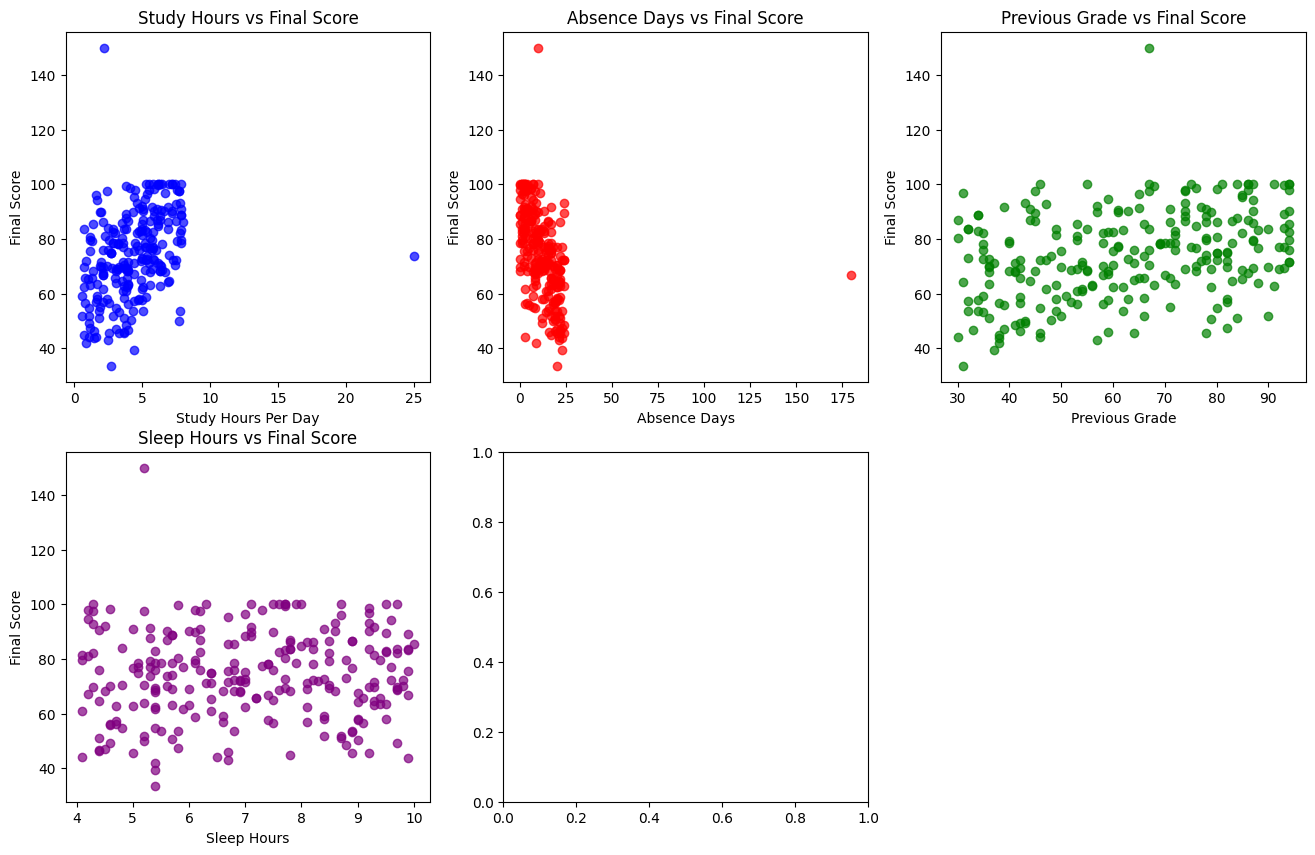

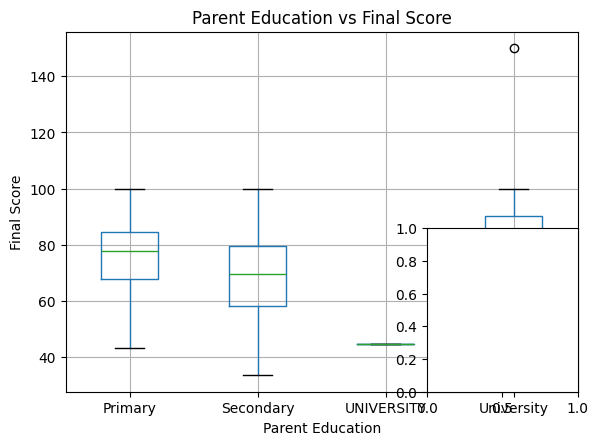

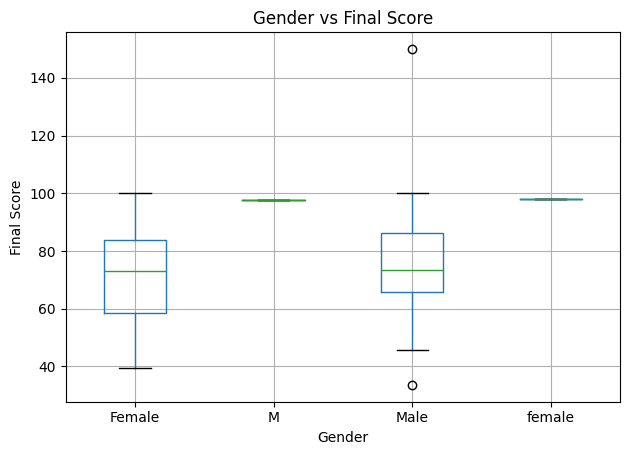

In [6]:
plt.figure(figsize=(16, 10))

# 1. Study Hours vs Final Score
plt.subplot(2, 3, 1)
plt.scatter(df['StudyHoursPerDay'], df['FinalScore'], color='blue', alpha=0.7)
plt.title('Study Hours vs Final Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Score')

# 2. Absence Days vs Final Score
plt.subplot(2, 3, 2)
plt.scatter(df['AbsenceDays'], df['FinalScore'], color='red', alpha=0.7)
plt.title('Absence Days vs Final Score')
plt.xlabel('Absence Days')
plt.ylabel('Final Score')

# 3. Previous Grade vs Final Score
plt.subplot(2, 3, 3)
plt.scatter(df['PreviousGrade'], df['FinalScore'], color='green', alpha=0.7)
plt.title('Previous Grade vs Final Score')
plt.xlabel('Previous Grade')
plt.ylabel('Final Score')

# 4. Sleep Hours vs Final Score
plt.subplot(2, 3, 4)
plt.scatter(df['SleepHours'], df['FinalScore'], color='purple', alpha=0.7)
plt.title('Sleep Hours vs Final Score')
plt.xlabel('Sleep Hours')
plt.ylabel('Final Score')

# 5. Parent Education vs Final Score
plt.subplot(2, 3, 5)
df.boxplot(column='FinalScore', by='ParentEducation')
plt.title('Parent Education vs Final Score')
plt.suptitle('')
plt.xlabel('Parent Education')
plt.ylabel('Final Score')

# 6. Gender vs Final Score
plt.subplot(2, 3, 6)
df.boxplot(column='FinalScore', by='Gender')
plt.title('Gender vs Final Score')
plt.suptitle('')
plt.xlabel('Gender')
plt.ylabel('Final Score')

plt.tight_layout()
plt.show()

    Overall Conclusion

The analysis shows that study hours, class attendance, and previous academic performance have the greatest influence on students' final scores.

Students who study 4–8 hours per day, attend classes regularly (0–10 absence days), and have higher previous grades (70–95) generally achieve 70–100 marks in the final examination.

In contrast, sleep hours and gender show little or no strong relationship with final scores, while parental education has a slight positive influence, with students whose parents have university education achieving somewhat higher median scores.

The graphs also contain a few outliers, such as final scores near 150 and 180 absence days, which may indicate unusual cases or data entry errors and should be investigated further.